# MegaGO Exploration: Module Network Visualization

This notebook explores how the number of GO terms used for MegaGO similarity affects module clustering.
We compare **top 10**, **top 20**, **top 30**, and **all** enriched GO terms per module.

For each configuration, similarity matrices are computed for **Biological Process (BP)**, **Molecular Function (MF)**, and **Cellular Component (CC)** ontologies.
The final similarity matrix used for clustering is the **average** of the three ontologies.

Modules are colored by **MegaGO-based hierarchical clusters** (instead of keyword-based GO categories).

**Prerequisites:**
- Run `Module_Overview_Generator.ipynb` first to generate the module overview CSV
- Cytoscape must be running for the Cytoscape visualization sections
- MegaGO installed in `LemonIte` conda environment

**Required Input Files:**
- `Module_Overview_Complete.csv` - Generated by Module_Overview_Generator.ipynb
- `Enrichr_all_enriched_pathways_up_per_module.csv` - Full pathway enrichment data

In [23]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import sys
import shutil
import warnings
import re
import glob
import subprocess
import itertools
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

In [24]:
# overlap adjustment helper available globally
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''Ensure module nodes are not too close.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for i,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[i+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    ang=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(ang), y1-shift*np.sin(ang))
                    pos[n2]=(x2+shift*np.cos(ang), y2+shift*np.sin(ang))
                    moved=True
    return pos



In [ ]:
# Configuration

base_dir = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree/'
os.chdir(base_dir)

# Input files
module_overview_file = 'Module_Overview_Complete_Expression_UC_vs_nonIBD.csv'
enrichment_all_file = './Enrichment/Modules_enrichr/Enrichr_top_10_enriched_pathways_up_per_module.csv'

# Output directory
output_dir = './Networks/megaGO_exploration'
os.makedirs(output_dir, exist_ok=True)

# MegaGO configurations to explore
megago_configs = {
    'top_10': 10,
    'top_20': 20,
    'top_30': 30,
    'all': None  # None means use all terms
}

# Regulator score files
percentile = 2
TF_score_file = f'./Lemon_out/Lovering.percentile{percentile}.txt'
metabolite_score_file = f'./Lemon_out/Metabolite.percentile{percentile}.txt'

print("Configuration loaded!")
print(f"Working directory: {base_dir}")
print(f"Output directory: {output_dir}")

Configuration loaded!
Working directory: /home/borisvdm/Documents/PhD/Lemonite/Wang_GBM/results/LemonTree/noProteomics_percentile2_divide_by_sum/
Output directory: ./Networks/megaGO_exploration


In [ ]:
# Load Module Overview Data
module_overview = pd.read_csv(module_overview_file, sep='\t')

"""
modules_to_process = module_overview['Module'].unique().tolist()

# ===== TEST WITH 3 MODULES =====
modules_to_process = modules_to_process[:3]  # Limit to first 3 modules for testing
module_overview = module_overview[module_overview['Module'].isin(modules_to_process)]  # Filter data accordingly
# ================================

print(f"Loaded module overview with {len(modules_to_process)} modules")
"""
modules_to_process = module_overview['Module'].unique().tolist()
print(f"Columns: {list(module_overview.columns)}")
module_overview.head()

Columns: ['Module', 'TF_regulators', 'Metabolite_regulators', 'Lipid_regulators', 'Expression_p_adjusted', 'Expression_rank', 'Expression_test_type', 'Expression_significant', 'PPI_FDR', 'PPI_fold_enrichment', 'Module_genes', 'Top_3_pathways_bio_process', 'Top_3_pathways_molecular_function', 'Top_3_pathways_cellular_component', 'Top_3_pathways_KEGG', 'Top_3_pathways_Reactome']


,Module,TF_regulators,Metabolite_regulators,Lipid_regulators,Expression_p_adjusted,Expression_rank,Expression_test_type,Expression_significant,PPI_FDR,PPI_fold_enrichment,Module_genes,Top_3_pathways_bio_process,Top_3_pathways_molecular_function,Top_3_pathways_cellular_component,Top_3_pathways_KEGG,Top_3_pathways_Reactome
0,7,TFAP2A|SNAI1|ZBTB8B|IRF6|FOXN1|ZNF215|FOXO6|SP7,creatinine,PE(16_0/22_6)|PC(16_0/16_1)_C|PC(16_0/16_1)_B|...,1.233980e-07,1,Kruskal-Wallis H-test,Yes,3.352941e-111,4.474665,TNFRSF11B|P4HA3|KCNK15|HAS3|CFI|MET|ARHGEF5|AC...,['Extracellular Matrix Organization (GO:003019...,['Platelet-Derived Growth Factor Binding (GO:0...,['Collagen-Containing Extracellular Matrix (GO...,"['Protein digestion and absorption_Up', 'Prote...","['Extracellular Matrix Organization_Up', 'Coll..."
1,2,CUX2|SOHLH1|MYT1L|DACH2|OLIG1,creatinine|L_cysteine|linoleic_acid,PC(18_1/36_6)|PC(20_4/36_5)|PS(20_4/22_6)|PE(1...,1.233980e-07,2,Kruskal-Wallis H-test,Yes,2.087947e-38,4.082854,REPS2|VSTM2B|RIMS2|HMGCLL1|LINGO2|SAMD12|DACH2...,"['Synapse Organization (GO:0050808)_Up', 'Chlo...",['Voltage-Gated Potassium Channel Activity (GO...,['Voltage-Gated Potassium Channel Complex (GO:...,"['Neuroactive ligand-receptor interaction_Up',...","['Neuronal System_Up', 'Transmission Across Ch..."
2,47,SOHLH1,creatinine|D_mannose|Unknown_026,PS(22_6/22_6)|PC(22_6/36_4)|PS(20_4/22_6)|PC(1...,1.233980e-07,3,Kruskal-Wallis H-test,Yes,1.000000e+00,0.000000,ATP4A|FAM19A4|GLRA1|SLC5A8|PYDC1|RBM11|OR2L5|Z...,['Sensory Perception of Smell (GO:0007608)_Up'...,['Olfactory Receptor Activity (GO:0004984)_Up'],[],['Olfactory transduction_Up'],['Expression and Translocation of Olfactory Re...
3,0,EMX1|SOHLH1|MYT1L,creatinine|L_lysine,PC(20_4/36_5)|PE(18_0/22_6)|PC(22_6/36_4)|PC(1...,1.233980e-07,4,Kruskal-Wallis H-test,Yes,2.722571e-188,9.003558,VSTM2L|GABRA5|SYT4|CREG2|SYNGR3|RBFOX1|KCNS1|S...,['Chemical Synaptic Transmission (GO:0007268)_...,['Chloride Transmembrane Transporter Activity ...,"['Synaptic Vesicle Membrane (GO:0030672)_Up', ...","['GABAergic synapse_Up', 'Nicotine addiction_U...","['Neuronal System_Up', 'Transmission Across Ch..."
4,1,SOHLH1|EMX1|PITX3,creatinine|D_mannose|pyrophosphate|Unknown_046,PC(20_4/36_5)|PC(22_6/36_4)|PS(22_6/22_6)|PE(1...,1.233980e-07,5,Kruskal-Wallis H-test,Yes,9.145338e-125,9.101836,GAD2|CACNG3|GJD2|NWD2|PCSK2|SYNPR|GABRG2|WSCD2...,['Chemical Synaptic Transmission (GO:0007268)_...,"['GABA Receptor Activity (GO:0016917)_Up', 'Be...","['Dendrite (GO:0030425)_Up', 'Neuron Projectio...","['Neuroactive ligand-receptor interaction_Up',...","['Neuronal System_Up', 'Transmission Across Ch..."


In [27]:
# Load Full Enrichment Data (all significant pathways)
module_enrichment_all = pd.read_csv(enrichment_all_file, sep=',')
module_enrichment_all['direction'] = 'Up'

print(f"Loaded enrichment data: {len(module_enrichment_all)} entries")
print(f"Databases: {list(module_enrichment_all['Database'].unique())}")
print(f"Modules with enrichment: {module_enrichment_all['Module'].nunique()}")

# Show how many BP terms per module
bp_counts = module_enrichment_all[module_enrichment_all['Database'] == 'BP'].groupby('Module').size()
print(f"\nBP terms per module:")
print(f"  Min: {bp_counts.min()}, Max: {bp_counts.max()}, Median: {bp_counts.median():.0f}")
print(f"  Modules with <10 BP terms: {(bp_counts < 10).sum()}")
print(f"  Modules with <20 BP terms: {(bp_counts < 20).sum()}")
print(f"  Modules with <30 BP terms: {(bp_counts < 30).sum()}")

Loaded enrichment data: 2840 entries
Databases: ['BP', 'MF', 'CC', 'KEGG', 'Reactome']
Modules with enrichment: 45

BP terms per module:
  Min: 1, Max: 208, Median: 33
  Modules with <10 BP terms: 10
  Modules with <20 BP terms: 17
  Modules with <30 BP terms: 18


In [28]:

# naive GO category assignment (keyword heuristic)
def categorize_modules_by_keywords(enrichment_df):
    """
    Very simple heuristic copied from `Module_Network_Visualization.ipynb`.
    Returns a dict mapping module id (string) → broad GO category.
    """
    go_categories = {
        'Immune': ['immune', 'inflammatory', 'cytokine', 'interferon', 'lymphocyte',
                   'leukocyte', 'antigen', 'defense', 'innate immunity', 'adaptive immunity',
                   'inflammation'],
        'Metabolic': ['metabolic', 'metabolism', 'biosynthetic', 'catabolic',
                      'glycolysis', 'oxidation', 'fatty acid', 'lipid metabolism',
                      'glucose', 'ATP'],
        'Cell Cycle': ['cell cycle', 'mitotic', 'division', 'proliferation',
                       'DNA replication', 'chromosome', 'cytokinesis', 'G1/S', 'G2/M'],
        'Signaling': ['signal transduction', 'signaling', 'receptor', 'kinase',
                      'phosphorylation', 'MAPK', 'cascade', 'pathway', 'GTPase'],
        'Development': ['development', 'differentiation', 'morphogenesis',
                        'embryonic', 'organogenesis', 'pattern specification'],
        'Apoptosis': ['apoptosis', 'cell death', 'programmed cell death',
                      'caspase'],
        'Adhesion_Migration': ['cell adhesion', 'migration', 'motility',
                               'locomotion', 'extracellular matrix', 'integrin'],
        'Transcription': ['transcription', 'RNA processing', 'gene expression',
                          'chromatin', 'histone', 'epigenetic'],
        'Transport': ['transport', 'localization', 'secretion', 'export',
                      'import', 'vesicle'],
        'Stress_Response': ['stress', 'response to stimulus', 'oxidative stress',
                            'DNA damage', 'hypoxia', 'heat shock']
    }

    module_categories = {}
    for module in enrichment_df['Module'].unique():
        mod_df = enrichment_df[enrichment_df['Module'] == module]
        bp_terms = mod_df[mod_df['Database'] == 'BP']['Term'].tolist()
        if not bp_terms:
            module_categories[str(module)] = 'Other'
            continue

        scores = {cat: 0 for cat in go_categories}
        for term in bp_terms:
            tl = term.lower()
            for cat, kws in go_categories.items():
                for kw in kws:
                    if kw in tl:
                        scores[cat] += 1

        if max(scores.values()) > 0:
            module_categories[str(module)] = max(scores, key=scores.get)
        else:
            module_categories[str(module)] = 'Other'
    return module_categories

# compute the naive labels for later comparison and plotting
naive_categories = categorize_modules_by_keywords(module_enrichment_all)
from collections import Counter
print("Naive GO category counts (keyword heuristic):")
print(Counter(naive_categories.values()))


Naive GO category counts (keyword heuristic):
Counter({'Signaling': 15, 'Metabolic': 9, 'Other': 8, 'Transport': 5, 'Development': 3, 'Adhesion_Migration': 2, 'Immune': 2, 'Cell Cycle': 1})


In [ ]:
# Load Regulator Score Data
print("Loading regulator scores...")
regulator_scores = {'TF': {}, 'metabolite': {}}

for reg_type, score_file in [('TF', TF_score_file), ('metabolite', metabolite_score_file)]:
    try:
        scores = pd.read_csv(score_file, sep='\t')
        if len(scores.columns) >= 3:
            scores = scores.iloc[:, [0, 1, 2]]
            scores.columns = ['Regulator', 'Module', 'Score']
            for _, row in scores.iterrows():
                key = (row['Regulator'], str(row['Module']))
                regulator_scores[reg_type][key] = row['Score']
            print(f"  Loaded {len(scores)} {reg_type} scores")
    except Exception as e:
        print(f"  Warning: Could not load {reg_type} scores: {e}")

Loading regulator scores...
  Loaded 249 TF scores
  Loaded 123 metabolite scores
  Loaded 352 lipid scores


In [ ]:
# Load PKN and metabolite mapping for edge categorization
print("Loading PKN and metabolite mapping for interaction classification...")
PKNnetwork_file = '/home/borisvdm/Documents/PhD/Lemonite/PKN/Lemonite_PKN.tsv'
PKN_df = pd.read_csv(PKNnetwork_file, sep='\t', header=0)
PKN_df['Node1'] = PKN_df['Node1'].astype(str).str.split('_').str[-1]
PKN_df['Node2'] = PKN_df['Node2'].astype(str).str.split('_').str[-1]

# metabolite name -> HMDB mapping (used to translate regulator labels)
annotated_mets_file = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/data/name_map.txt'
try:
    mapping_df = pd.read_csv(annotated_mets_file, sep='\t')
    name_to_hmdb = mapping_df.set_index('Query')['HMDB'].dropna().to_dict()
    print(f"  Loaded {len(name_to_hmdb)} metabolite mappings (name -> HMDB)")
except Exception as e:
    print(f"  Warning: could not load metabolite mapping: {e}")
    name_to_hmdb = {}

# helper for categorising individual PKN edges
def get_edge_type_category(source, edge_type):
    """Return interaction category for a single PKN edge."""
    if edge_type == 'metabolite-gene':
        causal_sources = ['LINCS', 'chEMBL']
        metabolic_sources = ['Human1_GEM_dist1', 'Human1_GEM_dist2']
        if source in causal_sources:
            return 'Causal'
        elif source in metabolic_sources:
            return 'Metabolic_pathway'
        else:
            return 'Other'
    elif edge_type == 'PPI':
        return 'PPI'
    else:
        return 'PPI'

# ------------------------------------------------------------------
# build lookup tables once (avoids repeated DataFrame filtering)
# ------------------------------------------------------------------

# module → list of gene symbols
module_genes_map = {}
for _, row in module_overview.iterrows():
    mid = str(row['Module'])
    if 'Module_genes' in row and pd.notna(row['Module_genes']) and row['Module_genes'] != 'NA':
        module_genes_map[mid] = str(row['Module_genes']).split('|')
    else:
        module_genes_map[mid] = []

# PKN pair lookup: (nodeA, nodeB) -> list of categories
pkn_lookup = {}
for _, r in PKN_df.iterrows():
    n1 = r['Node1']
    n2 = r['Node2']
    cat = get_edge_type_category(r['Source'], r['Type'])
    pkn_lookup.setdefault((n1, n2), []).append(cat)
    pkn_lookup.setdefault((n2, n1), []).append(cat)

# cache for regulator–module scores
_edge_cat_cache = {}

def categorize_regulator_module_edge(regulator, module):
    """Fast lookup of the best interaction category between a metabolite
    regulator and any gene of a module.

    The highest‑priority category found is returned (Causal >
    Metabolic_pathway > Other).  Uses `module_genes_map` and
    `pkn_lookup` built above.
    """
    hmdb = name_to_hmdb.get(regulator, regulator)
    best = 'Other'
    for gene in module_genes_map.get(str(module), []):
        cats = pkn_lookup.get((hmdb, gene), [])       # metabolite → gene
        if not cats:
            cats = pkn_lookup.get((gene, hmdb), [])   # gene → metabolite
        for c in cats:
            if c == 'Causal':
                return 'Causal'                     # short‑circuit
            elif c == 'Metabolic_pathway' and best != 'Causal':
                best = 'Metabolic_pathway'
    return best

def annotate_edges_with_category(edges):
    """Annotate a list of regulator→module edges.  Caches results to avoid
    recomputing identical pairs."""
    for edge in edges:
        if edge['type'].startswith('metabolite'):
            key = (edge['source'], edge['target'])
            if key in _edge_cat_cache:
                edge['category'] = _edge_cat_cache[key]
            else:
                reg = edge['source']
                mod = edge['target'].replace('Module_', '')
                cat = categorize_regulator_module_edge(reg, mod)
                edge['category'] = cat
                _edge_cat_cache[key] = cat
        else:
            edge['category'] = 'Other'
    return edges

Loading PKN and metabolite mapping for interaction classification...
  Loaded 74 metabolite mappings (name -> HMDB)


## Step 1: Create MegaGO Input Files for Each Configuration

For each configuration (top 10, 20, 30, all), extract GO term IDs from the enrichment data
for BP, MF, and CC ontologies and write them to files that MegaGO can read.

In [31]:
# Create MegaGO input files for each configuration (BP, MF, CC)
# Extract GO IDs from term strings with fallback
def extract_go_id(term):
    """Extract GO:XXXXXXX from a term string like 'Some Process (GO:0007268)'"""
    match = re.search(r'(GO:\d+)', term)
    if match:
        return match.group(1)
    # Fallback: if no GO ID found, use the term as-is (might be in different format)
    return term

# Create separate dataframes for each ontology
ontologies = ['BP', 'MF', 'CC']
ontology_data = {}

for ontology in ontologies:
    onto_data = module_enrichment_all[module_enrichment_all['Database'] == ontology].copy()
    onto_data['GO_ID'] = onto_data['Term'].apply(extract_go_id)
    onto_data = onto_data.dropna(subset=['GO_ID'])
    onto_data = onto_data.sort_values('p.adjust')
    ontology_data[ontology] = onto_data
    print(f"Total {ontology} terms: {len(onto_data)}")

# Show example GO IDs
for ontology in ontologies:
    sample_ids = ontology_data[ontology]['GO_ID'].head(3).tolist()
    print(f"Example {ontology} GO IDs: {sample_ids}")

# Create GO term files for each configuration and ontology
for config_name, top_n in megago_configs.items():
    config_dir = os.path.join(output_dir, f'megaGO_files_{config_name}')
    os.makedirs(config_dir, exist_ok=True)
    
    files_created = {}
    for ontology in ontologies:
        files_created[ontology] = 0
        onto_data = ontology_data[ontology]
        
        for module in modules_to_process:
            module_onto = onto_data[onto_data['Module'] == module]
            
            if top_n is not None:
                module_onto = module_onto.head(top_n)
            
            go_ids = module_onto['GO_ID'].tolist()
            
            if go_ids:
                # Write GO IDs to file with header
                with open(os.path.join(config_dir, f'{module}_{ontology}_terms.txt'), 'w') as f:
                    f.write('GO_TERM\n')
                    f.write('\n'.join(go_ids))
                files_created[ontology] += 1
    
    print(f"{config_name}: Created BP={files_created['BP']}, MF={files_created['MF']}, CC={files_created['CC']} GO term files (top_n={top_n})")


Total BP terms: 1664
Total MF terms: 377
Total CC terms: 179
Example BP GO IDs: ['GO:0051607', 'GO:0003341', 'GO:0030198']
Example MF GO IDs: ['GO:0005125', 'GO:0005126', 'GO:0008009']
Example CC GO IDs: ['GO:0062023', 'GO:0043005', 'GO:0097729']
top_10: Created BP=39, MF=32, CC=28 GO term files (top_n=10)
top_20: Created BP=39, MF=32, CC=28 GO term files (top_n=20)
top_30: Created BP=39, MF=32, CC=28 GO term files (top_n=30)
all: Created BP=39, MF=32, CC=28 GO term files (top_n=None)


## Step 2: Run MegaGO for Each Configuration and Ontology

Compute pairwise semantic similarity between all module pairs using the MegaGO CLI for BP, MF, and CC.
Then calculate the average similarity matrix across the three ontologies.

In [32]:
# Helper function to run a single MegaGO comparison
def run_megago_pair(args):
    """Run MegaGO for a single pair using shell execution with absolute paths"""
    i, j, file_i, file_j, megago_exe, ontology = args
    try:
        # Use absolute paths and shell=True (more reliable)
        cmd = f"{megago_exe} {os.path.abspath(file_i)} {os.path.abspath(file_j)}"
        
        result = subprocess.run(
            cmd,
            shell=True,
            capture_output=True,
            text=True,
            timeout=60
        )
        
        # Parse for ontology-specific score
        output = result.stdout.strip()
        score = None
        
        if result.returncode == 0 and output:
            # Define patterns for each ontology
            if ontology == 'BP':
                patterns = [
                    re.compile(r"biological_process\s*[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                    re.compile(r"biological_process[^\n]*?([0-9]*\.?[0-9]+)", re.IGNORECASE),
                    re.compile(r"bp[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                ]
            elif ontology == 'MF':
                patterns = [
                    re.compile(r"molecular_function\s*[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                    re.compile(r"molecular_function[^\n]*?([0-9]*\.?[0-9]+)", re.IGNORECASE),
                    re.compile(r"mf[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                ]
            elif ontology == 'CC':
                patterns = [
                    re.compile(r"cellular_component\s*[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                    re.compile(r"cellular_component[^\n]*?([0-9]*\.?[0-9]+)", re.IGNORECASE),
                    re.compile(r"cc[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                ]
            else:
                patterns = []
            
            for pattern in patterns:
                match = pattern.search(output)
                if match:
                    try:
                        score = float(match.group(1))
                        if 0 <= score <= 1:
                            break
                    except ValueError:
                        continue
        
        if score is not None:
            return (i, j, score, "Success")
        else:
            debug_info = result.stdout[:100] if output else f"RC:{result.returncode}"
            if result.stderr:
                debug_info += f" | stderr: {result.stderr[:50]}"
            return (i, j, None, debug_info)
    
    except subprocess.TimeoutExpired:
        return (i, j, None, "Timeout (60s)")
    except Exception as e:
        return (i, j, None, f"Exception: {str(e)[:80]}")


# Run MegaGO for each configuration and ontology
similarity_matrices = {}  # {config_name: averaged_matrix}
ontology_matrices = {}    # {(config_name, ontology): matrix_df}

# Find megago executable
import shutil
megago_executable = shutil.which("megago")
if megago_executable is None:
    # Try to find it in conda environment
    megago_executable = os.path.join(os.path.dirname(sys.executable), "megago")

if megago_executable and not os.path.exists(megago_executable):
    megago_executable = None

if megago_executable is None:
    print("⚠ WARNING: megago executable not found!")
    print("Trying: conda run -n LemonIte megago")
    megago_executable = "conda run -n LemonIte megago"

print(f"Using megago: {megago_executable}\n")

# Process each configuration
for config_name in megago_configs.keys():
    config_dir = os.path.join(output_dir, f'megaGO_files_{config_name}')
    
    print(f"\n{'='*60}")
    print(f"Running MegaGO for: {config_name}")
    print(f"{'='*60}")
    
    # Get module file paths
    bp_files = sorted(glob.glob(os.path.join(config_dir, '*_BP_terms.txt')))
    module_ids_with_files = []
    file_paths_bp = []
    for f in bp_files:
        mod_id = int(os.path.basename(f).replace('_BP_terms.txt', ''))
        module_ids_with_files.append(mod_id)
        file_paths_bp.append(f)
    
    n = len(module_ids_with_files)
    print(f"  Modules with GO files: {n}")
    
    if n == 0:
        print("  ⚠ No GO files found - skipping")
        continue
    
    # Process each ontology
    averaged_matrix = None
    
    for ontology in ['BP', 'MF', 'CC']:
        loaded_from_cache = False
        matrix_file = os.path.join(output_dir, f'megaGO_similarity_matrix_{config_name}_{ontology}.csv')
        
        # Check if matrix already exists (skip computation if so)
        if os.path.exists(matrix_file):
            print(f"\n  {ontology}: Loading existing similarity matrix")
            sim_df = pd.read_csv(matrix_file, index_col=0)
            ontology_matrices[(config_name, ontology)] = sim_df
            loaded_from_cache = True
        else:
            print(f"\n  {ontology}: Running MegaGO (8 parallel workers)")
            
            # Get file paths for this ontology
            onto_files = sorted(glob.glob(os.path.join(config_dir, f'*_{ontology}_terms.txt')))
            file_paths_onto = []
            for mod_id in module_ids_with_files:
                onto_file = os.path.join(config_dir, f'{mod_id}_{ontology}_terms.txt')
                if os.path.exists(onto_file):
                    file_paths_onto.append(onto_file)
                else:
                    print(f"    ⚠ Missing {ontology} file for module {mod_id}")
            
            # Initialize similarity matrix for this ontology
            sim_matrix = np.zeros((n, n))
            np.fill_diagonal(sim_matrix, 1.0)
            
            # Prepare all pairs
            pairs = list(itertools.combinations(range(n), 2))
            total_pairs = len(pairs)
            print(f"    Total pairs to compare: {total_pairs}")
            
            # Create list of arguments for parallel execution
            pair_args = [(i, j, file_paths_onto[i], file_paths_onto[j], megago_executable, ontology) 
                         for i, j in pairs if i < len(file_paths_onto) and j < len(file_paths_onto)]
            
            # Run in parallel using ThreadPoolExecutor
            completed = 0
            failed = 0
            success = 0
            failures = []
            
            with ThreadPoolExecutor(max_workers=10) as executor:
                futures = {executor.submit(run_megago_pair, args): args for args in pair_args}
                
                for future in as_completed(futures):
                    try:
                        i, j, score, status = future.result()
                        
                        if score is not None:
                            sim_matrix[i, j] = score
                            sim_matrix[j, i] = score
                            success += 1
                        else:
                            failed += 1
                            failures.append((i, j, status))
                        
                        completed += 1
                        
                        if completed % 10 == 0 or completed == total_pairs:
                            print(f"      {completed}/{total_pairs} pairs... (✓{success} ✗{failed})")
                    
                    except Exception as e:
                        failed += 1
                        completed += 1
            
            print(f"    Results: ✓{success}/{total_pairs}, ✗{failed}")
            
            if failures and len(failures) <= 5:
                print(f"    Failed pairs:")
                for i, j, status in failures[:5]:
                    print(f"      - ({i},{j}): {status[:80]}")
            
            # Save similarity matrix for this ontology
            labels = [f'Module_{m}' for m in module_ids_with_files]
            sim_df = pd.DataFrame(sim_matrix, index=labels, columns=labels)
            sim_df.to_csv(matrix_file)
            ontology_matrices[(config_name, ontology)] = sim_df
            print(f"    Saved: {matrix_file}")
        
        # Add to averaged matrix calculation
        if loaded_from_cache and (config_name, ontology) not in ontology_matrices:
            ontology_matrices[(config_name, ontology)] = sim_df
        
        sim_data = ontology_matrices[(config_name, ontology)].values
        if averaged_matrix is None:
            averaged_matrix = sim_data.copy()
        else:
            averaged_matrix += sim_data
    
    # Average the three ontology matrices
    averaged_matrix /= 3.0
    
    labels = [f'Module_{m}' for m in module_ids_with_files]
    avg_df = pd.DataFrame(averaged_matrix, index=labels, columns=labels)
    
    # Save averaged matrix
    avg_matrix_file = os.path.join(output_dir, f'megaGO_similarity_matrix_{config_name}_averaged.csv')
    avg_df.to_csv(avg_matrix_file)
    similarity_matrices[config_name] = avg_df
    print(f"\n  Averaged matrix (BP + MF + CC) / 3 saved: {avg_matrix_file}")

print(f"\nAll {len(similarity_matrices)} averaged similarity matrices ready.")


Using megago: /home/borisvdm/Software/miniconda3/envs/LemonIte/bin/megago


Running MegaGO for: top_10
  Modules with GO files: 39

  BP: Loading existing similarity matrix

  MF: Loading existing similarity matrix

  CC: Loading existing similarity matrix

  Averaged matrix (BP + MF + CC) / 3 saved: ./Networks/megaGO_exploration/megaGO_similarity_matrix_top_10_averaged.csv

Running MegaGO for: top_20
  Modules with GO files: 39

  BP: Loading existing similarity matrix

  MF: Loading existing similarity matrix

  CC: Loading existing similarity matrix

  Averaged matrix (BP + MF + CC) / 3 saved: ./Networks/megaGO_exploration/megaGO_similarity_matrix_top_20_averaged.csv

Running MegaGO for: top_30
  Modules with GO files: 39

  BP: Loading existing similarity matrix

  MF: Loading existing similarity matrix

  CC: Loading existing similarity matrix

  Averaged matrix (BP + MF + CC) / 3 saved: ./Networks/megaGO_exploration/megaGO_similarity_matrix_top_30_averaged.csv

Running MegaGO for

## Step 3: Cluster Modules Based on Averaged MegaGO Similarity

Use hierarchical clustering on the averaged MegaGO similarity matrices (computed from BP, MF, and CC)
to assign modules to clusters.


Clustering for: top_10
  Cluster_1: 4 modules
  Cluster_2: 7 modules
  Cluster_3: 12 modules
  Cluster_4: 5 modules
  Cluster_5: 11 modules

Clustering for: top_20
  Cluster_1: 4 modules
  Cluster_2: 7 modules
  Cluster_3: 13 modules
  Cluster_4: 3 modules
  Cluster_5: 12 modules

Clustering for: top_30
  Cluster_1: 11 modules
  Cluster_2: 11 modules
  Cluster_3: 3 modules
  Cluster_4: 5 modules
  Cluster_5: 9 modules

Clustering for: all
  Cluster_1: 7 modules
  Cluster_2: 4 modules
  Cluster_3: 11 modules
  Cluster_4: 3 modules
  Cluster_5: 14 modules


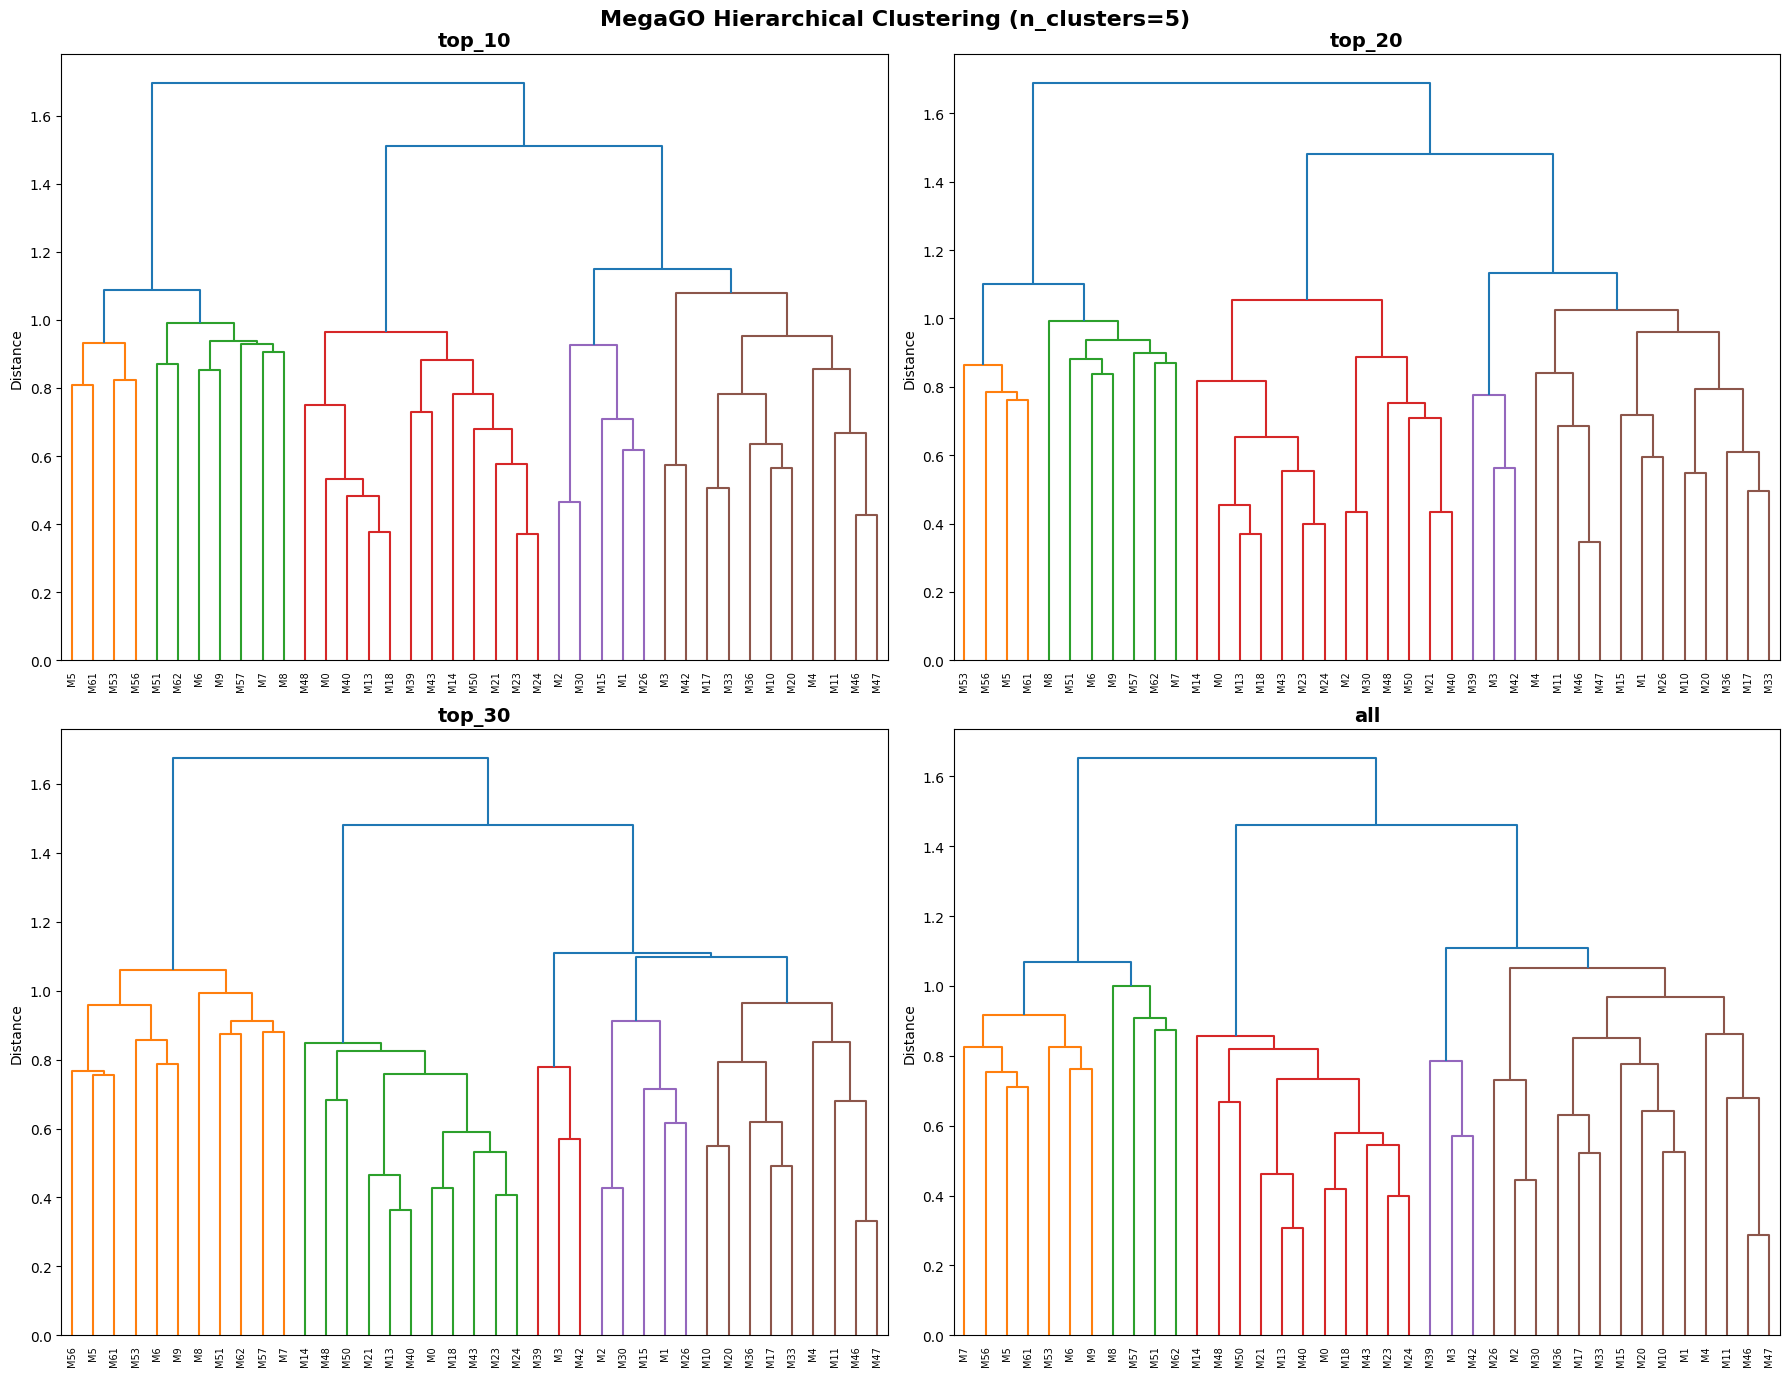


Dendrogram comparison saved.


In [33]:
# Cluster modules for each MegaGO configuration
cluster_assignments = {}  # {config_name: {module_id_str: cluster_label}}
linkage_results = {}

# Number of clusters - can be adjusted
n_clusters = 5

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (config_name, sim_df) in enumerate(similarity_matrices.items()):
    print(f"\nClustering for: {config_name}")
    
    # Convert similarity to distance
    sim_matrix = sim_df.values
    # Clip to [0, 1] range and convert to distance
    sim_clipped = np.clip(sim_matrix, 0, 1)
    dist_matrix = 1 - sim_clipped
    np.fill_diagonal(dist_matrix, 0)
    
    # Make symmetric (take average of upper/lower triangle)
    dist_matrix = (dist_matrix + dist_matrix.T) / 2
    
    # Hierarchical clustering
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='ward')
    linkage_results[config_name] = Z
    
    # Cut tree to get cluster assignments
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    
    module_labels = sim_df.index.tolist()
    module_clusters = {}
    for label, cluster in zip(module_labels, clusters):
        module_num = label.replace('Module_', '')
        module_clusters[module_num] = f'Cluster_{cluster}'
    
    cluster_assignments[config_name] = module_clusters
    
    # Print cluster sizes
    from collections import Counter
    cluster_counts = Counter(module_clusters.values())
    for c, count in sorted(cluster_counts.items()):
        print(f"  {c}: {count} modules")
    
    # Plot dendrogram
    ax = axes[idx]
    short_labels = [l.replace('Module_', 'M') for l in module_labels]
    dendrogram(Z, labels=short_labels, ax=ax, leaf_rotation=90, leaf_font_size=7,
               color_threshold=Z[-(n_clusters-1), 2])
    ax.set_title(f'{config_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Distance')

plt.suptitle(f'MegaGO Hierarchical Clustering (n_clusters={n_clusters})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dendrograms_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDendrogram comparison saved.")

In [34]:

# compare MegaGO clusters with the naive keyword categories
def rand_index_from_labels(lbl1, lbl2):
    n = len(lbl1)
    assert n == len(lbl2)
    agreements = 0
    total = 0
    for i in range(n):
        for j in range(i+1, n):
            same1 = lbl1[i] == lbl1[j]
            same2 = lbl2[i] == lbl2[j]
            if same1 == same2:
                agreements += 1
            total += 1
    return agreements / total if total else 0.0

print("\nComparison of MegaGO clusters with naive keyword categories")
print("=" * 60)
for cfg, assignments in cluster_assignments.items():
    mods = sorted(assignments.keys(), key=int)
    labels_meg = [assignments[m] for m in mods]
    labels_naive = [naive_categories.get(m, 'Other') for m in mods]

    ri = rand_index_from_labels(labels_meg, labels_naive)
    print(f"\n{cfg}: Rand index = {ri:.4f}  (n={len(mods)})")
    print(pd.crosstab(pd.Series(labels_naive, name='naive'),
                      pd.Series(labels_meg, name='megago')))



Comparison of MegaGO clusters with naive keyword categories

top_10: Rand index = 0.6694  (n=39)
megago              Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5
naive                                                                    
Adhesion_Migration          0          0          0          0          2
Cell Cycle                  0          0          1          0          0
Development                 0          1          1          1          0
Immune                      0          0          2          0          0
Metabolic                   0          3          2          0          4
Other                       0          0          0          0          2
Signaling                   4          3          4          1          3
Transport                   0          0          2          3          0

top_20: Rand index = 0.6613  (n=39)
megago              Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5
naive                                              

In [35]:
# Compare cluster stability across configurations
print("Cluster assignment comparison across MegaGO configurations:")
print("="*80)

# Build comparison table
all_modules = sorted(set().union(*[set(v.keys()) for v in cluster_assignments.values()]), key=int)
comparison_df = pd.DataFrame(index=all_modules)
for config_name, assignments in cluster_assignments.items():
    comparison_df[config_name] = comparison_df.index.map(lambda m: assignments.get(m, 'N/A'))

print(comparison_df.to_string())
comparison_df.to_csv(os.path.join(output_dir, 'cluster_assignments_comparison.csv'))
print(f"\nSaved to: {os.path.join(output_dir, 'cluster_assignments_comparison.csv')}")

Cluster assignment comparison across MegaGO configurations:
       top_10     top_20     top_30        all
0   Cluster_3  Cluster_3  Cluster_2  Cluster_3
1   Cluster_4  Cluster_5  Cluster_4  Cluster_5
2   Cluster_4  Cluster_3  Cluster_4  Cluster_5
3   Cluster_5  Cluster_4  Cluster_3  Cluster_4
4   Cluster_5  Cluster_5  Cluster_5  Cluster_5
5   Cluster_1  Cluster_1  Cluster_1  Cluster_1
6   Cluster_2  Cluster_2  Cluster_1  Cluster_1
7   Cluster_2  Cluster_2  Cluster_1  Cluster_1
8   Cluster_2  Cluster_2  Cluster_1  Cluster_2
9   Cluster_2  Cluster_2  Cluster_1  Cluster_1
10  Cluster_5  Cluster_5  Cluster_5  Cluster_5
11  Cluster_5  Cluster_5  Cluster_5  Cluster_5
13  Cluster_3  Cluster_3  Cluster_2  Cluster_3
14  Cluster_3  Cluster_3  Cluster_2  Cluster_3
15  Cluster_4  Cluster_5  Cluster_4  Cluster_5
17  Cluster_5  Cluster_5  Cluster_5  Cluster_5
18  Cluster_3  Cluster_3  Cluster_2  Cluster_3
20  Cluster_5  Cluster_5  Cluster_5  Cluster_5
21  Cluster_3  Cluster_3  Cluster_2  Cluster_3


## Step 4: Network Data Preparation

In [ ]:
# Network Data Preparation Function
def prepare_network_data():
    """Prepare nodes and edges for the interactive network visualization"""
    nodes = []
    edges = []
    regulator_modules = {'TF': {}, 'metabolite': {}}

    for _, row in module_overview.iterrows():
        module_id = str(row['Module'])
        hover_text = f"<b>Module {module_id}</b><br>"
        
        if 'Expression_p_value' in row and row['Expression_p_value'] != 'NA':
            hover_text += f"<b>Expression Analysis:</b><br>"
            hover_text += f"  \u2022 p-value: {row['Expression_p_value']:.2e}<br>"
            hover_text += f"  \u2022 Rank: {row['Expression_rank']}<br>"
            hover_text += f"  \u2022 Significant: {row['Expression_significant']}<br><br>"
        
        if row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
            gene_count = len(row['Module_genes'].split('|'))
            hover_text += f"<b>Genes:</b> {gene_count} genes<br>"

        module_node = {'id': f"Module_{module_id}", 'label': f"M{module_id}", 'type': 'module', 'hover_info': hover_text}
        nodes.append(module_node)

        if 'TF_regulators' in row and pd.notna(row['TF_regulators']) and row['TF_regulators'] != 'NA':
            for tf in [t.strip() for t in str(row['TF_regulators']).split('|') if t.strip()]:
                regulator_modules['TF'].setdefault(tf, []).append(module_id)

        if 'Metabolite_regulators' in row and pd.notna(row['Metabolite_regulators']) and row['Metabolite_regulators'] != 'NA':
            for met in [m.strip() for m in str(row['Metabolite_regulators']).split('|') if m.strip()]:
                regulator_modules['metabolite'].setdefault(met, []).append(module_id)

    for reg_type, regulators in regulator_modules.items():
        for regulator, target_modules in regulators.items():
            reg_node = {
                'id': regulator, 'label': regulator, 'type': reg_type,
                'hover_info': f"<b>{reg_type.upper()}:</b> {regulator}<br><b>Targets ({len(target_modules)}):</b> M{', M'.join(target_modules)}"
            }
            nodes.append(reg_node)
            for m in target_modules:
                edges.append({'source': regulator, 'target': f"Module_{m}", 'type': f"{reg_type}_to_module"})

    print(f"Network data prepared: {len(nodes)} nodes, {len(edges)} edges")
    return nodes, edges, regulator_modules

print("Network data preparation function defined!")

Network data preparation function defined!


In [ ]:
# Regulator Filtering Function with Score-based Selection
def filter_top_regulators(nodes, edges, regulator_scores, min_targets=3, max_regulators_per_type=20,
                          min_score=None, top_pairs_by_score=5):
    """Filter regulators based on connectivity and also include top regulator-module pairs by score."""
    node_types = {n['id']: n['type'] for n in nodes}
    regulator_targets = {}
    regulator_avg_scores = {}
    all_scored_pairs = []
    
    for edge in edges:
        source = edge['source']
        if source in node_types and node_types[source] in ['TF', 'metabolite']:
            if source not in regulator_targets:
                regulator_targets[source] = []
            target_module = edge['target'].replace('Module_', '')
            regulator_targets[source].append(target_module)
            
            reg_type = node_types[source]
            score_dict = regulator_scores.get(reg_type, {})
            pair_score = score_dict.get((source, target_module), 0)
            all_scored_pairs.append({
                'regulator': source, 'module': target_module, 'target': edge['target'],
                'score': pair_score, 'type': reg_type
            })
            
            scores = [score_dict.get((source, mod), 0) for mod in regulator_targets[source]]
            regulator_avg_scores[source] = sum(scores) / len(scores) if scores else 0
    
    regulators_by_type = {'TF': [], 'metabolite': []}
    for reg_id, target_list in regulator_targets.items():
        count = len(target_list)
        avg_score = regulator_avg_scores.get(reg_id, 0)
        if count >= min_targets:
            if min_score is None or avg_score >= min_score:
                reg_type = node_types[reg_id]
                regulators_by_type[reg_type].append((reg_id, count, avg_score))
    
    selected_regulators = set()
    connectivity_edges = []
    
    for reg_type, regs in regulators_by_type.items():
        sorted_regs = sorted(regs, key=lambda x: (x[1], x[2]), reverse=True)
        if len(sorted_regs) <= max_regulators_per_type:
            selected_regulators.update([r[0] for r in sorted_regs])
        else:
            cutoff_count = sorted_regs[max_regulators_per_type - 1][1]
            top_regs = [r for r in sorted_regs if r[1] >= cutoff_count]
            selected_regulators.update([r[0] for r in top_regs[:max_regulators_per_type]])
    
    for edge in edges:
        if edge['source'] in selected_regulators or edge['source'].startswith('Module_'):
            connectivity_edges.append(edge)
    
    scored_pairs_by_type = {'TF': [], 'metabolite': []}
    for pair in all_scored_pairs:
        scored_pairs_by_type[pair['type']].append(pair)
    
    top_scoring_pairs = []
    for reg_type in ['TF', 'metabolite']:
        sorted_pairs = sorted(scored_pairs_by_type[reg_type], key=lambda x: x['score'], reverse=True)
        top_scoring_pairs.extend(sorted_pairs[:top_pairs_by_score])
    
    score_based_edges = []
    for pair in top_scoring_pairs:
        selected_regulators.add(pair['regulator'])
        edge_obj = {'source': pair['regulator'], 'target': pair['target'], 'type': f"{pair['type']}_to_module"}
        if edge_obj not in connectivity_edges and edge_obj not in score_based_edges:
            score_based_edges.append(edge_obj)
    
    all_filtered_edges = connectivity_edges + score_based_edges
    filtered_nodes = [n for n in nodes if n['type'] == 'module' or n['id'] in selected_regulators]
    
    regulators_by_type_with_scores = {}
    for reg_type, regs in regulators_by_type.items():
        regulators_by_type_with_scores[reg_type] = [(r[0], r[1], r[2]) for r in regs]
    
    return filtered_nodes, all_filtered_edges, regulators_by_type_with_scores, top_scoring_pairs

print("Regulator filtering function defined!")

Regulator filtering function defined!


In [38]:
# Prepare network data and filter regulators (shared across all configs)
print("Preparing network data...")
nodes, edges, regulator_modules = prepare_network_data()

# annotate edges with interaction category based on PKN
edges = annotate_edges_with_category(edges)
from collections import Counter
print("Edge categories distribution:", Counter([e.get('category','Other') for e in edges]))

# keep a copy of the unfiltered network so we can also generate a full view
full_nodes, full_edges = nodes, edges

print("\nFiltering regulators...")
filtered_nodes, filtered_edges, regulator_stats, top_pairs = filter_top_regulators(
    nodes, edges, regulator_scores,
    min_targets=3, max_regulators_per_type=10,
    min_score=None, top_pairs_by_score=5
)
print(f"Filtered: {len(filtered_nodes)} nodes, {len(filtered_edges)} edges")

# dictionary of network variants we will use later
network_variants = {
    'filtered': (filtered_nodes, filtered_edges),
    'full': (full_nodes, full_edges)
}

Preparing network data...
Network data prepared: 349 nodes, 596 edges
Edge categories distribution: Counter({'Other': 564, 'Metabolic_pathway': 32})

Filtering regulators...
Filtered: 74 nodes, 192 edges


## Step 5: visualization in python html network

This section will create **two versions** of the module‑regulator network for each MegaGO configuration:
- a **filtered** network that retains only top regulators (as before)
- a **full** network with no selection, i.e. every node and edge generated from the data

Both variants are written out with distinct filenames and exported to Cytoscape later.

In [39]:
# helper to spread overlapping module nodes
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''Ensure every pair of module nodes are at least min_dist apart.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for i,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[i+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    angle=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(angle), y1-shift*np.sin(angle))
                    pos[n2]=(x2+shift*np.cos(angle), y2+shift*np.sin(angle))
                    moved=True
    return pos


In [ ]:
# ensure overlap helper available when networks are built
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''Pull overlapping module nodes apart.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for j,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[j+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    ang=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(ang), y1-shift*np.sin(ang))
                    pos[n2]=(x2+shift*np.cos(ang), y2+shift*np.sin(ang))
                    moved=True
    return pos

# helper overlapping modules
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''push module nodes apart until min_dist apart.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for j,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[j+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    ang=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(ang), y1-shift*np.sin(ang))
                    pos[n2]=(x2+shift*np.cos(ang), y2+shift*np.sin(ang))
                    moved=True
    return pos

# Interactive HTML Network Visualization (Plotly) - colored by MegaGO cluster
import plotly.graph_objects as go


def create_megago_cluster_layout(nodes, edges, module_clusters):
    """Create layout where modules are positioned based on their MegaGO cluster."""
    clusters = list(set(module_clusters.values()))
    n_clusters_layout = len(clusters)
    
    cluster_positions = {}
    for i, cl in enumerate(clusters):
        angle = 2 * np.pi * i / n_clusters_layout
        radius = 8
        cluster_positions[cl] = (radius * np.cos(angle), radius * np.sin(angle))
    
    pos = {}
    modules_by_cluster = {cl: [] for cl in clusters}
    for node in nodes:
        if node['type'] == 'module':
            module_id = node['id'].replace('Module_', '')
            cl = module_clusters.get(module_id, 'Unassigned')
            if cl not in modules_by_cluster:
                modules_by_cluster[cl] = []
            modules_by_cluster[cl].append(node['id'])
    
    np.random.seed(42)
    for cl, module_ids in modules_by_cluster.items():
        if cl not in cluster_positions:
            cluster_positions[cl] = (0, 0)
        center_x, center_y = cluster_positions[cl]
        n_modules = len(module_ids)
        
        if n_modules == 1:
            pos[module_ids[0]] = (center_x, center_y)
        else:
            for i, mod_id in enumerate(module_ids):
                angle = 2 * np.pi * i / n_modules
                jitter_radius = min(2.5, 0.5 + 0.3 * n_modules)
                x = center_x + jitter_radius * np.cos(angle)
                y = center_y + jitter_radius * np.sin(angle)
                pos[mod_id] = (x, y)
    
    # Position regulator nodes near their targets
    for node in nodes:
        if node['id'] not in pos:
            connected_modules = [e['target'] for e in edges if e['source'] == node['id']]
            if connected_modules:
                # determine cluster membership of targets
                connected_clusters = set(
                    module_clusters.get(m.replace('Module_', ''), 'Unassigned')
                    for m in connected_modules
                )
                connected_pos = [pos[m] for m in connected_modules if m in pos]
                if connected_pos:
                    if len(connected_clusters) == 1:
                        # if all targets in single cluster, start at cluster center
                        center_x, center_y = cluster_positions[next(iter(connected_clusters))]
                    else:
                        # otherwise average the module positions
                        center_x = np.mean([p[0] for p in connected_pos])
                        center_y = np.mean([p[1] for p in connected_pos])
                    offset_dist = 1.5
                    if node['type'] == 'TF':
                        angle_offset = 0
                    elif node['type'] == 'metabolite':
                        angle_offset = 2 * np.pi / 3
                    else:
                        angle_offset = 4 * np.pi / 3
                    offset_x = offset_dist * np.cos(angle_offset + np.random.normal(0, 0.5))
                    offset_y = offset_dist * np.sin(angle_offset + np.random.normal(0, 0.5))
                    pos[node['id']] = (center_x + offset_x, center_y + offset_y)
                else:
                    pos[node['id']] = (0, 0)
            else:
                pos[node['id']] = (0, 0)
    
    return pos, cluster_positions


def build_enriched_hover_text(module_id, module_overview, module_enrichment_all, edges):
    """Build rich hover text for a module node including expression, regulators, and enrichment info."""
    hover_text = f"<b>Module {module_id}</b><br>"
    row = module_overview[module_overview['Module'].astype(str) == str(module_id)]
    if len(row) > 0:
        row = row.iloc[0]
        # Expression analysis
        if 'Expression_p_value' in row.index and row['Expression_p_value'] != 'NA':
            try:
                hover_text += f"<b>Expression Analysis:</b><br>"
                hover_text += f"  \u2022 p-value: {float(row['Expression_p_value']):.2e}<br>"
                hover_text += f"  \u2022 Rank: {row['Expression_rank']}<br>"
                hover_text += f"  \u2022 Significant: {row['Expression_significant']}<br><br>"
            except (ValueError, TypeError):
                pass
        # Gene count
        if 'Module_genes' in row.index and row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
            gene_count = len(str(row['Module_genes']).split('|'))
            hover_text += f"<b>Genes:</b> {gene_count} genes<br><br>"
    # Regulators per type
    module_target = f"Module_{module_id}"
    reg_type_labels = {'TF': 'Transcription Factors', 'metabolite': 'Metabolites'}
    for reg_type, reg_label in reg_type_labels.items():
        regs = sorted(set(e['source'] for e in edges if e['target'] == module_target and e['type'] == f"{reg_type}_to_module"))
        if regs:
            hover_text += f"<b>{reg_label} ({len(regs)}):</b> "
            hover_text += ', '.join(regs[:10])
            if len(regs) > 10:
                hover_text += f", ... (+{len(regs)-10} more)"
            hover_text += '<br>'
    hover_text += '<br>'
    # Top enriched pathways from ALL databases (BP, MF, CC, KEGG, Reactome)
    if module_enrichment_all is not None and not module_enrichment_all.empty:
        mod_enrich = module_enrichment_all[module_enrichment_all['Module'].astype(str) == str(module_id)]
        for db in ['BP', 'MF', 'CC', 'KEGG', 'Reactome']:
            db_enrich = mod_enrich[mod_enrich['Database'] == db].sort_values('p.adjust').head(3)
            if len(db_enrich) > 0:
                hover_text += f"<b>Top {db}:</b><br>"
                for _, erow in db_enrich.iterrows():
                    term = str(erow['Term'])
                    if len(term) > 55:
                        term = term[:52] + '...'
                    p_val = erow['p.adjust']
                    hover_text += f"  \u2022 {term} (p={p_val:.1e})<br>"
    return hover_text


def create_megago_interactive_network(nodes, edges, module_clusters, config_name,
                                      module_overview, module_enrichment_all, movable=False):
    """Create interactive Plotly network with modules colored by MegaGO cluster.

    If ``movable`` is True each node is placed in its own scatter trace so the
    resulting HTML (with ``config={'editable': True}``) lets you click‑and‑drag
    individual points to avoid overlaps.
    """
    # build enriched hover info & optionally split into per-node traces later
    enriched_nodes = []
    for node in nodes:
        enriched_node = dict(node)
        if node['type'] == 'module':
            module_id = node['id'].replace('Module_', '')
            enriched_node['hover_info'] = build_enriched_hover_text(
                module_id, module_overview, module_enrichment_all, edges
            )
            # Add cluster info to hover
            cluster = module_clusters.get(module_id, 'Unassigned')
            enriched_node['hover_info'] += f"<br><b>MegaGO Cluster:</b> {cluster}"
        enriched_nodes.append(enriched_node)
    # create layout positions
    pos, cluster_positions = create_megago_cluster_layout(enriched_nodes, edges, module_clusters)

    # color palette
    all_clusters = sorted(set(module_clusters.values()))
    cluster_palette = ['#EE6677', '#4477AA', '#228833', '#AA3377', '#66CCEE',
                       '#CCBB44', '#EE99AA', '#44BB99', '#BBCC33', '#AAAA00']
    cluster_color_map = {cl: cluster_palette[i % len(cluster_palette)] for i, cl in enumerate(all_clusters)}
    cluster_color_map['Unassigned'] = '#BBBBBB'
    regulator_color = '#FF8C00'

    # prepare edge traces by interaction category (Causal, Metabolic_pathway, Other)
    edge_styles = {
        'Causal': {'color': 'rgba(80,80,80,0.9)', 'width': 3.0, 'label': 'Causal'},
        'Metabolic_pathway': {'color': 'rgba(80,80,80,0.85)', 'width': 2.5, 'label': 'Metabolic pathway'},
        'Other': {'color': 'rgba(80,80,80,0.6)', 'width': 1.5, 'label': 'Other'}
    }
    edge_traces = {}
    for cat, style in edge_styles.items():
        edge_traces[cat] = go.Scatter(x=[], y=[],
                                      line=dict(width=style['width'], color=style['color']),
                                      hoverinfo='none', mode='lines',
                                      name=style['label'], showlegend=True)

    # accumulate coordinates into appropriate category traces
    # use temporary dicts because Scatter.x/y always return tuples
    temp_coords = {cat: {'x': [], 'y': []} for cat in edge_traces}
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat not in temp_coords:
                cat = 'Other'
            temp_coords[cat]['x'].extend([x0, x1, None])
            temp_coords[cat]['y'].extend([y0, y1, None])

    # assign the accumulated lists back to the traces
    for cat, coords in temp_coords.items():
        edge_traces[cat].x = coords['x']
        edge_traces[cat].y = coords['y']

    # build figure with edge traces (draw Other first so thicker edges overlay)
    fig = go.Figure()
    for cat in ['Other', 'Metabolic_pathway', 'Causal']:
        fig.add_trace(edge_traces[cat])

    # ------------------------------------------------------------------
    # decorate the end of some edges
    # ------------------------------------------------------------------
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat == 'Causal':
                # arrowhead pointing at the target
                fig.add_annotation(
                    x=x1, y=y1, ax=x0, ay=y0,
                    xref='x', yref='y', axref='x', ayref='y',
                    showarrow=True, arrowhead=3, arrowsize=1,
                    arrowwidth=edge_styles[cat]['width'],
                    arrowcolor=edge_styles[cat]['color'],
                    opacity=0.8
                )
            elif cat == 'Metabolic_pathway':
                # tiny dot at the target end
                fig.add_trace(go.Scatter(
                    x=[x1], y=[y1], mode='markers',
                    marker=dict(symbol='circle', size=6,
                                color=edge_styles[cat]['color'], line=dict(width=0)),
                    hoverinfo='none', showlegend=False
                ))

    if movable:
        # one trace per node to allow individual dragging
        for n in enriched_nodes:
            x = pos.get(n['id'], (0,0))[0]
            y = pos.get(n['id'], (0,0))[1]
            label = n.get('label', n['id'])
            txt = label if n['type']=='module' else label[:15]
            symbol = 'circle' if n['type']=='module' else 'diamond-wide'
            color = cluster_color_map.get(module_clusters.get(n['id'].replace('Module_',''), ''), '#BBBBBB') if n['type']=='module' else regulator_color
            size = 50 if n['type']=='module' else min(80, max(25, len(txt)*4))
            fig.add_trace(go.Scatter(x=[x], y=[y], mode='markers+text',
                                     marker=dict(size=size, color=color,
                                                 line=dict(width=2 if n['type']=='module' else 1, color='white' if n['type']=='module' else 'darkorange'),
                                                 symbol=symbol),
                                     text=[txt], textposition='middle center',
                                     textfont=dict(size=12 if n['type']=='module' else 8, color='black', family='Arial Black'),
                                     hovertext=[n.get('hover_info', txt)], hoverinfo='text',
                                     name=n['id'], showlegend=False))
    else:
        # grouped module traces by cluster
        module_traces = []
        for cluster in all_clusters:
            cat_nodes = [n for n in enriched_nodes if n['type']=='module' and
                         module_clusters.get(n['id'].replace('Module_',''),'Unassigned')==cluster]
            if not cat_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in cat_nodes]
            y_vals = [pos[n['id']][1] for n in cat_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in cat_nodes]
            labels = [n['id'].replace('Module_','') for n in cat_nodes]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color=cluster_color_map.get(cluster,'#CCCCCC'),
                                          line=dict(width=2, color='white'), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{cluster} ({len(cat_nodes)})", legendgroup=cluster)
            module_traces.append(trace)
        for tr in module_traces:
            fig.add_trace(tr)
        # unassigned
        unassigned_nodes = [n for n in enriched_nodes if n['type']=='module' and
                            module_clusters.get(n['id'].replace('Module_',''),'Unassigned')=='Unassigned']
        if unassigned_nodes:
            x_vals = [pos[n['id']][0] for n in unassigned_nodes]
            y_vals = [pos[n['id']][1] for n in unassigned_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in unassigned_nodes]
            labels = [n['id'].replace('Module_','') for n in unassigned_nodes]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color='#BBBBBB',
                                          line=dict(width=2, color='white'), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f'Unassigned ({len(unassigned_nodes)})', legendgroup='Unassigned')
            fig.add_trace(trace)
        # regulator traces grouped by type
        regulator_traces = []
        for reg_type in ['TF','metabolite']:
            reg_nodes = [n for n in enriched_nodes if n['type']==reg_type]
            if not reg_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in reg_nodes]
            y_vals = [pos[n['id']][1] for n in reg_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in reg_nodes]
            labels = [n['label'][:15] if len(n['label'])>15 else n['label'] for n in reg_nodes]
            sizes = [min(80, max(25, len(label)*4)) for label in labels]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=sizes, color=regulator_color, symbol='diamond-wide',
                                          line=dict(width=1, color='darkorange')),
                              text=labels, textposition='middle center',
                              textfont=dict(size=8, color='black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{reg_type.capitalize()} ({len(reg_nodes)})", legendgroup=f'reg_{reg_type}')
            regulator_traces.append(trace)
        for tr in regulator_traces:
            fig.add_trace(tr)
    # annotations for clusters
    annotations = []
    for cl, (x, y) in cluster_positions.items():
        annotations.append(dict(x=x*1.3, y=y*1.3, text=f'<b>{cl}</b>', showarrow=False,
                               font=dict(size=14, color=cluster_color_map.get(cl,'#000000')),
                               bgcolor='rgba(255,255,255,0.8)', borderpad=4))
    fig.update_layout(
        title=dict(text=f'Module-Regulator Network<br><sub>Modules colored by MegaGO cluster ({config_name})</sub>',
                   x=0.5, font=dict(size=20)),
        showlegend=True, hovermode='closest', width=1400, height=1000,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white', annotations=annotations,
        legend=dict(x=1.02, y=1, bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='black', borderwidth=1, font=dict(size=10))
    )
    # for editable figures we don't need a special dragmode – configuration
    # passed to write_html (editable=True) already allows dragging individual
    # points.  Setting an unsupported value caused a ValueError earlier.
    return fig

# Generate interactive HTML networks for each MegaGO configuration
print("=" * 60)
print("INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters)")
print("=" * 60)

# iterate over variants (filtered vs full) so we can produce both versions
for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
    for config_name, module_clusters in cluster_assignments.items():
        print(f"Generating {variant_name} network for: {config_name}")
        config_subdir = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_subdir, exist_ok=True)
        fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all
        )
        html_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}.html')
        fig.write_html(html_path)
        print(f"  Saved: {html_path}")
        try:
            png_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}.png')
            fig.write_image(png_path, width=1400, height=1000, scale=2)
            print(f"  Saved: {png_path}")
        except Exception as e:
            print(f"  Note: Could not export PNG: {e}")
        fig.show()

        mov_fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all, movable=True
        )
        mov_html = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}_movable.html')
        mov_fig.write_html(mov_html, config={'editable': True})
        print(f"  Saved movable version: {mov_html}")


print(f"All interactive HTML networks saved to: {output_dir}")

INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters)
Generating filtered network for: top_10
  Saved: ./Networks/megaGO_exploration/top_10/filtered/module_network_filtered_megaGO_top_10.html
  Saved: ./Networks/megaGO_exploration/top_10/filtered/module_network_filtered_megaGO_top_10.png


  Saved movable version: ./Networks/megaGO_exploration/top_10/filtered/module_network_filtered_megaGO_top_10_movable.html
Generating filtered network for: top_20
  Saved: ./Networks/megaGO_exploration/top_20/filtered/module_network_filtered_megaGO_top_20.html
  Saved: ./Networks/megaGO_exploration/top_20/filtered/module_network_filtered_megaGO_top_20.png


  Saved movable version: ./Networks/megaGO_exploration/top_20/filtered/module_network_filtered_megaGO_top_20_movable.html
Generating filtered network for: top_30
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30.png


  Saved movable version: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30_movable.html
Generating filtered network for: all
  Saved: ./Networks/megaGO_exploration/all/filtered/module_network_filtered_megaGO_all.html
  Saved: ./Networks/megaGO_exploration/all/filtered/module_network_filtered_megaGO_all.png


  Saved movable version: ./Networks/megaGO_exploration/all/filtered/module_network_filtered_megaGO_all_movable.html
Generating full network for: top_10
  Saved: ./Networks/megaGO_exploration/top_10/full/module_network_full_megaGO_top_10.html
  Saved: ./Networks/megaGO_exploration/top_10/full/module_network_full_megaGO_top_10.png


  Saved movable version: ./Networks/megaGO_exploration/top_10/full/module_network_full_megaGO_top_10_movable.html
Generating full network for: top_20
  Saved: ./Networks/megaGO_exploration/top_20/full/module_network_full_megaGO_top_20.html
  Saved: ./Networks/megaGO_exploration/top_20/full/module_network_full_megaGO_top_20.png


  Saved movable version: ./Networks/megaGO_exploration/top_20/full/module_network_full_megaGO_top_20_movable.html
Generating full network for: top_30
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30.png


  Saved movable version: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30_movable.html
Generating full network for: all
  Saved: ./Networks/megaGO_exploration/all/full/module_network_full_megaGO_all.html
  Saved: ./Networks/megaGO_exploration/all/full/module_network_full_megaGO_all.png


  Saved movable version: ./Networks/megaGO_exploration/all/full/module_network_full_megaGO_all_movable.html
All interactive HTML networks saved to: ./Networks/megaGO_exploration


In [ ]:
# re-define the interactive network function to include naive-category borders
import plotly.graph_objects as go

def create_megago_interactive_network(nodes, edges, module_clusters, config_name,
                                      module_overview, module_enrichment_all,
                                      movable=False, naive_categories=None):
    """Create interactive Plotly network with modules coloured by MegaGO
    cluster.  If ``naive_categories`` is given (module→category dict), the
    border of each module node is coloured according to the naive
    assignment.
    """
    # build enriched hover info & optionally split into per-node traces later
    enriched_nodes = []
    for node in nodes:
        enriched_node = dict(node)
        if node['type'] == 'module':
            module_id = node['id'].replace('Module_', '')
            enriched_node['hover_info'] = build_enriched_hover_text(
                module_id, module_overview, module_enrichment_all, edges
            )
            # Add cluster info to hover
            cluster = module_clusters.get(module_id, 'Unassigned')
            enriched_node['hover_info'] += f"<br><b>MegaGO Cluster:</b> {cluster}"
        enriched_nodes.append(enriched_node)
    # create layout positions
    pos, cluster_positions = create_megago_cluster_layout(enriched_nodes, edges, module_clusters)

    # colour palettes for the two schemes
    all_clusters = sorted(set(module_clusters.values()))
    cluster_palette = ['#EE6677', '#4477AA', '#228833', '#AA3377', '#66CCEE',
                       '#CCBB44', '#EE99AA', '#44BB99', '#BBCC33', '#AAAA00']
    cluster_color_map = {cl: cluster_palette[i % len(cluster_palette)]
                         for i, cl in enumerate(all_clusters)}
    cluster_color_map['Unassigned'] = '#BBBBBB'

    naive_color_map = {}
    if naive_categories is not None:
        naives = sorted(set(naive_categories.values()))
        naive_palette = ['#FFD700', '#ADFF2F', '#00FA9A', '#FF69B4',
                         '#BA55D3', '#FFA500', '#87CEFA', '#40E0D0']
        naive_color_map = {cl: naive_palette[i % len(naive_palette)]
                           for i, cl in enumerate(naives)}
        naive_color_map['Other'] = '#DDDDDD'

    regulator_color = '#FF8C00'

    # prepare edge traces by interaction category (Causal, Metabolic_pathway, Other)
    edge_styles = {
        'Causal': {'color': 'rgba(80,80,80,0.9)', 'width': 3.0, 'label': 'Causal'},
        'Metabolic_pathway': {'color': 'rgba(80,80,80,0.85)', 'width': 2.5, 'label': 'Metabolic pathway'},
        'Other': {'color': 'rgba(80,80,80,0.6)', 'width': 1.5, 'label': 'Other'}
    }
    edge_traces = {}
    for cat, style in edge_styles.items():
        edge_traces[cat] = go.Scatter(x=[], y=[],
                                      line=dict(width=style['width'], color=style['color']),
                                      hoverinfo='none', mode='lines',
                                      name=style['label'], showlegend=True)

    # accumulate coordinates into appropriate category traces
    temp_coords = {cat: {'x': [], 'y': []} for cat in edge_traces}
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat not in temp_coords:
                cat = 'Other'
            temp_coords[cat]['x'].extend([x0, x1, None])
            temp_coords[cat]['y'].extend([y0, y1, None])

    for cat, coords in temp_coords.items():
        edge_traces[cat].x = coords['x']
        edge_traces[cat].y = coords['y']

    # build figure with edge traces (draw Other first so thicker edges overlay)
    fig = go.Figure()
    for cat in ['Other', 'Metabolic_pathway', 'Causal']:
        fig.add_trace(edge_traces[cat])

    # ------------------------------------------------------------------
    # decorate the end of some edges
    # ------------------------------------------------------------------
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat == 'Causal':
                fig.add_annotation(
                    x=x1, y=y1, ax=x0, ay=y0,
                    xref='x', yref='y', axref='x', ayref='y',
                    showarrow=True, arrowhead=3, arrowsize=1,
                    arrowwidth=edge_styles[cat]['width'],
                    arrowcolor=edge_styles[cat]['color'],
                    opacity=0.8
                )
            elif cat == 'Metabolic_pathway':
                fig.add_trace(go.Scatter(
                    x=[x1], y=[y1], mode='markers',
                    marker=dict(symbol='circle', size=6,
                                color=edge_styles[cat]['color'], line=dict(width=0)),
                    hoverinfo='none', showlegend=False
                ))

    if movable:
        # one trace per node to allow individual dragging
        for n in enriched_nodes:
            x = pos.get(n['id'], (0,0))[0]
            y = pos.get(n['id'], (0,0))[1]
            label = n.get('label', n['id'])
            txt = label if n['type']=='module' else label[:15]
            symbol = 'circle' if n['type']=='module' else 'diamond-wide'
            color = cluster_color_map.get(module_clusters.get(n['id'].replace('Module_',''), ''), '#BBBBBB') if n['type']=='module' else regulator_color
            size = 50 if n['type']=='module' else min(80, max(25, len(txt)*4))
            border = '#FFFFFF'
            if n['type'] == 'module' and naive_categories is not None:
                m_id = n['id'].replace('Module_','')
                border = naive_color_map.get(naive_categories.get(m_id,'Other'), '#FFFFFF')
            fig.add_trace(go.Scatter(x=[x], y=[y], mode='markers+text',
                                     marker=dict(size=size, color=color,
                                                 line=dict(width=3, color=border),
                                                 symbol=symbol),
                                     text=[txt], textposition='middle center',
                                     textfont=dict(size=12 if n['type']=='module' else 8, color='black', family='Arial Black'),
                                     hovertext=[n.get('hover_info', txt)], hoverinfo='text',
                                     name=n['id'], showlegend=False))

    else:
        # grouped module traces by cluster
        module_traces = []
        for cluster in all_clusters:
            cat_nodes = [n for n in enriched_nodes if n['type']=='module' and
                         module_clusters.get(n['id'].replace('Module_',''),'Unassigned')==cluster]
            if not cat_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in cat_nodes]
            y_vals = [pos[n['id']][1] for n in cat_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in cat_nodes]
            labels = [n['id'].replace('Module_','') for n in cat_nodes]
            # compute border colours per module
            line_colours = []
            for n in cat_nodes:
                m_id = n['id'].replace('Module_','')
                if naive_categories is not None:
                    line_colours.append(naive_color_map.get(naive_categories.get(m_id,'Other'), 'white'))
                else:
                    line_colours.append('white')
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color=cluster_color_map.get(cluster,'#CCCCCC'),
                                          line=dict(width=3, color=line_colours), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{cluster} ({len(cat_nodes)})", legendgroup=cluster)
            module_traces.append(trace)
        for tr in module_traces:
            fig.add_trace(tr)
        # unassigned nodes (same as before)
        unassigned_nodes = [n for n in enriched_nodes if n['type']=='module' and
                            module_clusters.get(n['id'].replace('Module_',''),'Unassigned')=='Unassigned']
        if unassigned_nodes:
            x_vals = [pos[n['id']][0] for n in unassigned_nodes]
            y_vals = [pos[n['id']][1] for n in unassigned_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in unassigned_nodes]
            labels = [n['id'].replace('Module_','') for n in unassigned_nodes]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color='#BBBBBB',
                                          line=dict(width=3, color=['white']*len(x_vals)), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f'Unassigned ({len(unassigned_nodes)})', legendgroup='Unassigned')
            fig.add_trace(trace)
        # regulator traces grouped by type (unchanged)
        regulator_traces = []
        for reg_type in ['TF','metabolite']:
            reg_nodes = [n for n in enriched_nodes if n['type']==reg_type]
            if not reg_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in reg_nodes]
            y_vals = [pos[n['id']][1] for n in reg_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in reg_nodes]
            labels = [n['label'][:15] if len(n['label'])>15 else n['label'] for n in reg_nodes]
            sizes = [min(80, max(25, len(label)*4)) for label in labels]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=sizes, color=regulator_color, symbol='diamond-wide',
                                          line=dict(width=1, color='darkorange')),
                              text=labels, textposition='middle center',
                              textfont=dict(size=8, color='black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{reg_type.capitalize()} ({len(reg_nodes)})", legendgroup=f'reg_{reg_type}')
            regulator_traces.append(trace)
        for tr in regulator_traces:
            fig.add_trace(tr)
    # annotations for clusters
    annotations = []
    for cl, (x, y) in cluster_positions.items():
        annotations.append(dict(x=x*1.3, y=y*1.3, text=f'<b>{cl}</b>', showarrow=False,
                               font=dict(size=14, color=cluster_color_map.get(cl,'#000000')),
                               bgcolor='rgba(255,255,255,0.8)', borderpad=4))
    fig.update_layout(
        title=dict(text=f'Module-Regulator Network<br><sub>Modules colored by MegaGO cluster ({config_name})</sub>',
                   x=0.5, font=dict(size=20)),
        showlegend=True, hovermode='closest', width=1400, height=1000,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white', annotations=annotations,
        legend=dict(x=1.02, y=1, bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='black', borderwidth=1, font=dict(size=10))
    )
    # add naive legend
    if naive_categories is not None:
        for cat, col in naive_color_map.items():
            fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
                                     marker=dict(size=20, color='white',
                                                 line=dict(width=3, color=col)),
                                     name=f'naive:{cat}', showlegend=True))
    return fig

# now regenerate html networks using the updated function
print("=" * 60)
print("INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters + naive borders)")
print("=" * 60)

for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
    for config_name, module_clusters in cluster_assignments.items():
        print(f"Generating {variant_name} network for: {config_name} (with naive labels)")
        config_subdir = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_subdir, exist_ok=True)
        fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all,
            naive_categories=naive_categories
        )
        html_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}_with_naive.html')
        fig.write_html(html_path)
        print(f"  Saved: {html_path}")
        try:
            png_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}_with_naive.png')
            fig.write_image(png_path, width=1400, height=1000, scale=2)
            print(f"  Saved: {png_path}")
        except Exception as e:
            print(f"  Note: Could not export PNG: {e}")
        fig.show()

        mov_fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all,
            movable=True, naive_categories=naive_categories
        )
        mov_html = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}_movable_with_naive.html')
        mov_fig.write_html(mov_html, config={'editable': True})
        print(f"  Saved movable version: {mov_html}")
print(f"All interactive HTML networks with naive color borders saved to: {output_dir}")


INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters + naive borders)
Generating filtered network for: top_10 (with naive labels)
  Saved: ./Networks/megaGO_exploration/top_10/filtered/module_network_filtered_megaGO_top_10_with_naive.html
  Saved: ./Networks/megaGO_exploration/top_10/filtered/module_network_filtered_megaGO_top_10_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/top_10/filtered/module_network_filtered_megaGO_top_10_movable_with_naive.html
Generating filtered network for: top_20 (with naive labels)
  Saved: ./Networks/megaGO_exploration/top_20/filtered/module_network_filtered_megaGO_top_20_with_naive.html
  Saved: ./Networks/megaGO_exploration/top_20/filtered/module_network_filtered_megaGO_top_20_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/top_20/filtered/module_network_filtered_megaGO_top_20_movable_with_naive.html
Generating filtered network for: top_30 (with naive labels)
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30_with_naive.html
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30_movable_with_naive.html
Generating filtered network for: all (with naive labels)
  Saved: ./Networks/megaGO_exploration/all/filtered/module_network_filtered_megaGO_all_with_naive.html
  Saved: ./Networks/megaGO_exploration/all/filtered/module_network_filtered_megaGO_all_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/all/filtered/module_network_filtered_megaGO_all_movable_with_naive.html
Generating full network for: top_10 (with naive labels)
  Saved: ./Networks/megaGO_exploration/top_10/full/module_network_full_megaGO_top_10_with_naive.html
  Saved: ./Networks/megaGO_exploration/top_10/full/module_network_full_megaGO_top_10_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/top_10/full/module_network_full_megaGO_top_10_movable_with_naive.html
Generating full network for: top_20 (with naive labels)
  Saved: ./Networks/megaGO_exploration/top_20/full/module_network_full_megaGO_top_20_with_naive.html
  Saved: ./Networks/megaGO_exploration/top_20/full/module_network_full_megaGO_top_20_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/top_20/full/module_network_full_megaGO_top_20_movable_with_naive.html
Generating full network for: top_30 (with naive labels)
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30_with_naive.html
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30_movable_with_naive.html
Generating full network for: all (with naive labels)
  Saved: ./Networks/megaGO_exploration/all/full/module_network_full_megaGO_all_with_naive.html
  Saved: ./Networks/megaGO_exploration/all/full/module_network_full_megaGO_all_with_naive.png


  Saved movable version: ./Networks/megaGO_exploration/all/full/module_network_full_megaGO_all_movable_with_naive.html
All interactive HTML networks with naive color borders saved to: ./Networks/megaGO_exploration


## Step 6: Cytoscape Visualization for Each MegaGO Configuration

Create a Cytoscape network for each configuration, with modules colored by MegaGO cluster.

In [42]:
# Export Cytoscape-compatible files for each configuration and variant
for config_name, module_clusters in cluster_assignments.items():
    for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
        print(f"\nExporting Cytoscape files for: {config_name} ({variant_name})")
        
        config_output = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_output, exist_ok=True)
        
        cytoscape_sif = os.path.join(config_output, 'module_network_edges.txt')
        cytoscape_node_attr = os.path.join(config_output, 'module_network_node_attributes.txt')
        # cytoscape_edge_attr = os.path.join(config_output, 'module_network_edge_attributes.txt')
        
        # combined edge list + attributes
        with open(cytoscape_sif, 'w') as f:
            f.write("source\ttarget\tCategory\tArrowShape\n")
            for edge in edges_to_use:
                cat = edge.get('category', 'Other')
                if cat == 'Causal':
                    arrow = 'DELTA'
                elif cat == 'Metabolic_pathway':
                    arrow = 'DOT'
                else:
                    arrow = ''
                f.write(f"{edge['source']}\t{edge['target']}\t{cat}\t{arrow}\n")
        
        # node attributes (add expression/PPI/gene-count for modules)
        with open(cytoscape_node_attr, 'w') as f:
            f.write("Node\tMegaGO_Cluster\tNode_Type\tExpression_significant\tPPI_significant\tModule_genes_count\n")
            for node in nodes_to_use:
                node_id = node['id']
                node_type = node['type']
                if node_type == 'module':
                    module_num = node_id.replace('Module_', '')
                    cluster = module_clusters.get(module_num, 'Unassigned')
                    # look up extra info in module_overview
                    row = module_overview[module_overview['Module'].astype(str) == module_num]
                    expr_flag = ''
                    ppi_flag = ''
                    gene_count = ''
                    if len(row) > 0:
                        try:
                            expr_flag = 'Yes' if row.iloc[0].get('Expression_significant', '') == 'Yes' else 'No'
                        except Exception:
                            expr_flag = ''
                        try:
                            ppi_val = row.iloc[0].get('PPI_FDR', np.nan)
                            ppi_flag = 'Yes' if pd.notna(ppi_val) and ppi_val < 0.05 else 'No'
                        except Exception:
                            ppi_flag = ''
                        try:
                            genes = row.iloc[0].get('Module_genes', '')
                            gene_count = len(str(genes).split('|')) if pd.notna(genes) and genes != 'NA' else 0
                        except Exception:
                            gene_count = ''
                    f.write(f"{node_id}\t{cluster}\t{node_type}\t{expr_flag}\t{ppi_flag}\t{gene_count}\n")
                else:
                    # regulators: leave new columns empty
                    f.write(f"{node_id}\t\t{node_type}\t\t\t\n")
        
        print(f"  Saved edge list + attributes: {cytoscape_sif}")
        print(f"  Saved node attrs: {cytoscape_node_attr}")

print("\nAll Cytoscape files exported.")



Exporting Cytoscape files for: top_10 (filtered)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_10/filtered/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_10/filtered/module_network_node_attributes.txt

Exporting Cytoscape files for: top_10 (full)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_10/full/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_10/full/module_network_node_attributes.txt

Exporting Cytoscape files for: top_20 (filtered)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_20/filtered/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_20/filtered/module_network_node_attributes.txt

Exporting Cytoscape files for: top_20 (full)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_20/full/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_20/full/module_network_node_attributes.txt

Exporti

## Create Interactive Cytoscape.js Networks with Draggable Nodes

In [60]:
import json

# Same palette used in the Plotly network visualisations
CLUSTER_PALETTE = ['#EE6677', '#4477AA', '#228833', '#AA3377', '#66CCEE',
                   '#CCBB44', '#EE99AA', '#44BB99', '#BBCC33', '#AAAA00']
UNASSIGNED_COLOR = '#B0B0B0'
REGULATOR_COLOR  = '#FF8C00'

def build_cluster_color_map(module_clusters):
    """Build a cluster-name → colour mapping from the actual cluster assignments."""
    all_clusters = sorted(set(v for v in module_clusters.values() if v != 'Unassigned'))
    color_map = {cl: CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)] for i, cl in enumerate(all_clusters)}
    color_map['Unassigned'] = UNASSIGNED_COLOR
    return color_map

def create_cytoscape_html_network(nodes, edges, module_clusters, config_name, 
                                   variant_name, output_file):
    """
    Create an interactive Cytoscape.js network with draggable nodes.
    
    Parameters:
    -----------
    nodes : list of dict
        Node definitions with 'id', 'label', 'type'
    edges : list of dict
        Edge definitions with 'source', 'target', 'category'
    module_clusters : dict
        Mapping of module numbers to cluster assignments
    config_name : str
        Configuration name for title
    variant_name : str
        Variant name for title
    output_file : str
        Path to save the HTML file
    """
    
    try:
        # Build colour map from actual cluster names
        cluster_color_map = build_cluster_color_map(module_clusters)
        
        # Build Cytoscape elements
        cy_nodes = []
        for node in nodes:
            node_id = str(node['id'])
            node_type = str(node['type'])
            
            if node_type == 'module':
                module_num = node_id.replace('Module_', '')
                label = f"M{module_num}"
                cluster = module_clusters.get(module_num, 'Unassigned')
                color = cluster_color_map.get(cluster, UNASSIGNED_COLOR)
                node_class = 'module'
            else:
                label = str(node.get('label', node_id))[:20]  # Truncate long labels
                cluster = None
                color = REGULATOR_COLOR
                node_class = 'regulator'
            
            cy_nodes.append({
                'data': {
                    'id': node_id,
                    'label': label,
                    'type': node_type,
                    'cluster': cluster if cluster else 'N/A'
                },
                'classes': node_class,
                'style': {
                    'background-color': color
                }
            })
        
        cy_edges = []
        edge_colors = {
            'Causal': '#2C3E50',
            'Metabolic_pathway': '#E74C3C',
            'Other': '#95A5A6'
        }
        
        for edge in edges:
            category = str(edge.get('category', 'Other'))
            color = edge_colors.get(category, '#95A5A6')
            source = str(edge['source'])
            target = str(edge['target'])
            
            cy_edges.append({
                'data': {
                    'id': f"{source}-{target}",
                    'source': source,
                    'target': target,
                    'category': category
                },
                'style': {
                    'line-color': color,
                    'target-arrow-color': color
                }
            })
        
        # Serialize elements to JSON
        elements_json = json.dumps(cy_nodes + cy_edges, indent=2)
        
        # Build legend items dynamically from actual cluster colours
        legend_items_html = ""
        for cl_name, cl_color in cluster_color_map.items():
            legend_items_html += (
                f'        <div class="legend-item">\n'
                f'            <div class="legend-color" style="background: {cl_color};"></div>\n'
                f'            <span class="legend-label">{cl_name}</span>\n'
                f'        </div>\n'
            )
        
        # Generate HTML
        html_content = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>Network: {config_name} - {variant_name}</title>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/cytoscape/3.23.0/cytoscape.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/layout-base@2.0.1/layout-base.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/cose-base@2.2.0/cose-base.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/cytoscape-cose-bilkent@4.1.0/cytoscape-cose-bilkent.js"></script>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}
        
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            overflow: hidden;
        }}
        
        #cy {{
            width: 100%;
            height: calc(100vh - 100px);
            display: block;
            background: linear-gradient(to bottom, #f5f5f5 0%, #ffffff 100%);
        }}
        
        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 15px 20px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        
        .header h1 {{
            margin: 0;
            font-size: 20px;
        }}
        
        .header p {{
            margin: 5px 0 0 0;
            font-size: 12px;
            opacity: 0.9;
        }}
        
        .controls {{
            position: absolute;
            top: 110px;
            left: 20px;
            background: white;
            border: 1px solid #ddd;
            border-radius: 4px;
            padding: 15px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            z-index: 100;
            font-size: 12px;
        }}
        
        .control-group {{
            margin-bottom: 12px;
        }}
        
        .control-group label {{
            display: block;
            font-weight: bold;
            margin-bottom: 5px;
            color: #333;
        }}
        
        button {{
            padding: 8px 12px;
            margin: 3px 0;
            cursor: pointer;
            background: #667eea;
            color: white;
            border: none;
            border-radius: 3px;
            font-size: 11px;
            font-weight: 600;
            transition: background 0.2s;
            display: block;
            width: 100%;
        }}
        
        button:hover {{
            background: #764ba2;
        }}
        
        .legend {{
            position: absolute;
            bottom: 20px;
            right: 20px;
            background: white;
            border: 1px solid #ddd;
            border-radius: 4px;
            padding: 15px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            font-size: 12px;
            max-width: 250px;
        }}
        
        .legend-item {{
            display: flex;
            align-items: center;
            margin-bottom: 8px;
        }}
        
        .legend-color {{
            width: 20px;
            height: 20px;
            border-radius: 50%;
            margin-right: 8px;
            border: 2px solid #fff;
        }}
        
        .legend-line {{
            width: 30px;
            height: 0;
            margin-right: 8px;
        }}
        
        .legend-label {{
            color: #333;
        }}
        
        .info-box {{
            position: absolute;
            bottom: 20px;
            left: 20px;
            background: white;
            border: 1px solid #ddd;
            border-radius: 4px;
            padding: 10px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            font-size: 11px;
            color: #666;
            max-width: 250px;
        }}

        .search-box {{
            position: relative;
        }}

        .search-box input {{
            width: 100%;
            padding: 6px 8px;
            border: 1px solid #ccc;
            border-radius: 3px;
            font-size: 11px;
            outline: none;
        }}

        .search-box input:focus {{
            border-color: #667eea;
        }}

        .autocomplete-list {{
            position: absolute;
            top: 100%;
            left: 0;
            right: 0;
            background: white;
            border: 1px solid #ccc;
            border-top: none;
            border-radius: 0 0 3px 3px;
            max-height: 150px;
            overflow-y: auto;
            z-index: 200;
            display: none;
        }}

        .autocomplete-list div {{
            padding: 4px 8px;
            cursor: pointer;
            font-size: 11px;
        }}

        .autocomplete-list div:hover,
        .autocomplete-list div.active {{
            background: #667eea;
            color: white;
        }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Network Analysis: {config_name}</h1>
        <p>Variant: {variant_name} | Nodes: {len(cy_nodes)} | Edges: {len(cy_edges)}</p>
    </div>
    
    <div id="cy"></div>
    
    <div class="controls">
        <div class="control-group">
            <label>Layout:</label>
            <button onclick="runLayout('cose-bilkent')">CoSE Bilkent</button>
            <button onclick="runLayout('concentric')">Concentric</button>
            <button onclick="runLayout('breadthfirst')">Breadth-First</button>
        </div>
        
        <div class="control-group">
            <label>Actions:</label>
            <button onclick="fitView()">Fit View</button>
            <button onclick="resetView()">Reset</button>
            <button onclick="exportPositions()">Export Positions</button>
        </div>

        <div class="control-group">
            <label>Search:</label>
            <div class="search-box">
                <input type="text" id="searchInput" placeholder="Type node name..." autocomplete="off" />
                <div class="autocomplete-list" id="autocompleteList"></div>
            </div>
            <button onclick="clearHighlight()" style="margin-top:6px">Clear Highlight</button>
        </div>
    </div>
    
    <div class="legend">
        <strong>Node types:</strong>
        <div class="legend-item">
            <div class="legend-color" style="background: {REGULATOR_COLOR};"></div>
            <span class="legend-label">Regulator</span>
        </div>
{legend_items_html}
        <hr style="margin: 8px 0; border: none; border-top: 1px solid #ddd;">
        <strong>Edge types:</strong>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 3px solid #2C3E50;"></div>
            <span class="legend-label">Causal</span>
        </div>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 2px dashed #E74C3C;"></div>
            <span class="legend-label">Metabolic pathway</span>
        </div>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 1px solid #95A5A6;"></div>
            <span class="legend-label">Other</span>
        </div>
    </div>
    
    <div class="info-box">
        <strong>Controls:</strong><br>
        &bull; Drag nodes to move<br>
        &bull; Scroll to zoom<br>
        &bull; Pan with right-click drag<br>
        &bull; Click nodes for info
    </div>
    
    <script>
        // Register cose-bilkent extension
        if (typeof cytoscapeCoseBilkent !== 'undefined') {{
            cytoscape.use(cytoscapeCoseBilkent);
        }}
        
        // Build elements data
        var elements = {elements_json};
        
        // Initialize Cytoscape
        var cy = cytoscape({{
            container: document.getElementById('cy'),
            elements: elements,
            
            style: [
                {{
                    selector: 'node.module',
                    style: {{
                        'label': 'data(label)',
                        'width': '65px',
                        'height': '65px',
                        'border-width': '3px',
                        'border-color': 'rgba(255, 255, 255, 0.8)',
                        'text-valign': 'center',
                        'text-halign': 'center',
                        'font-size': '13px',
                        'font-weight': 'bold',
                        'color': '#fff',
                        'text-outline-width': '2px',
                        'text-outline-color': 'rgba(0, 0, 0, 0.3)',
                        'cursor': 'grab'
                    }}
                }},
                {{
                    selector: 'node.regulator',
                    style: {{
                        'label': 'data(label)',
                        'width': '50px',
                        'height': '50px',
                        'border-width': '2px',
                        'border-color': 'rgba(255, 255, 255, 0.7)',
                        'text-valign': 'center',
                        'text-halign': 'center',
                        'font-size': '11px',
                        'color': '#fff',
                        'text-outline-width': '1px',
                        'text-outline-color': 'rgba(0, 0, 0, 0.3)',
                        'cursor': 'grab'
                    }}
                }},
                {{
                    selector: 'node:selected',
                    style: {{
                        'border-width': '4px',
                        'border-color': '#FFD700',
                        'shadow-blur': '10px',
                        'shadow-color': 'rgba(0, 0, 0, 0.5)',
                        'shadow-offset-x': '0px',
                        'shadow-offset-y': '4px'
                    }}
                }},
                {{
                    selector: 'edge[category="Causal"]',
                    style: {{
                        'width': '3px',
                        'target-arrow-shape': 'triangle',
                        'target-arrow-fill': 'filled',
                        'curve-style': 'bezier',
                        'opacity': 0.8
                    }}
                }},
                {{
                    selector: 'edge[category="Metabolic_pathway"]',
                    style: {{
                        'width': '2px',
                        'target-arrow-shape': 'circle',
                        'target-arrow-fill': 'filled',
                        'curve-style': 'bezier',
                        'line-dash-pattern': [5, 5],
                        'opacity': 0.7
                    }}
                }},
                {{
                    selector: 'edge[category="Other"]',
                    style: {{
                        'width': '1px',
                        'curve-style': 'bezier',
                        'opacity': 0.5
                    }}
                }},
                {{
                    selector: 'edge:selected',
                    style: {{
                        'width': '4px',
                        'opacity': 1,
                        'shadow-blur': '8px',
                        'shadow-color': 'rgba(0, 0, 0, 0.4)'
                    }}
                }},
                {{
                    selector: '.dimmed',
                    style: {{
                        'opacity': 0.15
                    }}
                }},
                {{
                    selector: '.highlighted',
                    style: {{
                        'opacity': 1,
                        'border-width': '4px',
                        'border-color': '#FFD700'
                    }}
                }}
            ],
            
            layout: {{
                name: 'cose-bilkent',
                directed: false,
                animate: true,
                animationDuration: 800,
                fit: true,
                padding: 50,
                nodeSpacing: 5,
                edgeElasticity: 0.45,
                nestingFactor: 0.1,
                gravity: 0.25,
                numIter: 2500,
                tile: true
            }},
            
            wheelSensitivity: 0.1,
            autoungrabify: false,
            userPanningEnabled: true
        }});
        
        // Store initial layout positions
        var initialPositions = {{}};
        cy.on('layoutstop', function() {{
            cy.nodes().forEach(function(node) {{
                initialPositions[node.id()] = {{x: node.position('x'), y: node.position('y')}};
            }});
        }});
        
        // Node click: display info
        cy.on('tap', 'node', function(e) {{
            var node = e.target;
            var info = 'ID: ' + node.data('id') + '\\nType: ' + node.data('type') + '\\nCluster: ' + node.data('cluster');
            console.log('Node info:', info);
        }});
        
        // Global functions
        window.runLayout = function(layoutName) {{
            var layout = cy.layout({{
                name: layoutName,
                directed: false,
                animate: true,
                animationDuration: 500,
                fit: true,
                padding: 50,
                nodeSpacing: layoutName === 'cose-bilkent' ? 5 : 10
            }});
            layout.run();
        }};
        
        window.fitView = function() {{
            cy.fit(undefined, 50);
        }};
        
        window.resetView = function() {{
            cy.nodes().forEach(function(node) {{
                var pos = initialPositions[node.id()];
                if (pos) {{
                    node.position(pos);
                }}
            }});
            cy.fit(undefined, 50);
        }};
        
        window.exportPositions = function() {{
            var positions = {{}};
            cy.nodes().forEach(function(node) {{
                positions[node.id()] = {{
                    x: Math.round(node.position('x')),
                    y: Math.round(node.position('y'))
                }};
            }});
            
            var dataStr = JSON.stringify(positions, null, 2);
            var dataUri = 'data:application/json;charset=utf-8,' + encodeURIComponent(dataStr);
            var exportFileDefaultName = 'network_positions_{config_name}_{variant_name}.json';
            
            var linkElement = document.createElement('a');
            linkElement.setAttribute('href', dataUri);
            linkElement.setAttribute('download', exportFileDefaultName);
            linkElement.click();
            
            console.log('Positions exported:', positions);
        }};
        
        console.log('Cytoscape network initialized with ' + cy.nodes().length + ' nodes and ' + cy.edges().length + ' edges');

        // --- Search & Highlight ---
        var allNodeNames = [];
        cy.nodes().forEach(function(n) {{
            allNodeNames.push({{ id: n.id(), label: n.data('label'), display: n.data('id') }});
        }});

        var searchInput = document.getElementById('searchInput');
        var acList = document.getElementById('autocompleteList');
        var acIndex = -1;

        function renderAC(matches) {{
            acList.innerHTML = '';
            acIndex = -1;
            if (matches.length === 0) {{ acList.style.display = 'none'; return; }}
            matches.forEach(function(m) {{
                var div = document.createElement('div');
                div.textContent = m.display;
                div.addEventListener('mousedown', function(e) {{
                    e.preventDefault();
                    searchInput.value = m.display;
                    acList.style.display = 'none';
                    highlightNode(m.id);
                }});
                acList.appendChild(div);
            }});
            acList.style.display = 'block';
        }}

        searchInput.addEventListener('input', function() {{
            var q = this.value.toLowerCase();
            if (q.length === 0) {{ acList.style.display = 'none'; clearHighlight(); return; }}
            var matches = allNodeNames.filter(function(n) {{
                return n.id.toLowerCase().indexOf(q) !== -1 || n.label.toLowerCase().indexOf(q) !== -1;
            }}).slice(0, 15);
            renderAC(matches);
        }});

        searchInput.addEventListener('keydown', function(e) {{
            var items = acList.querySelectorAll('div');
            if (e.key === 'ArrowDown') {{ e.preventDefault(); acIndex = Math.min(acIndex + 1, items.length - 1); }}
            else if (e.key === 'ArrowUp') {{ e.preventDefault(); acIndex = Math.max(acIndex - 1, 0); }}
            else if (e.key === 'Enter') {{
                e.preventDefault();
                if (acIndex >= 0 && items[acIndex]) {{ items[acIndex].dispatchEvent(new Event('mousedown')); }}
                else if (items.length > 0) {{ items[0].dispatchEvent(new Event('mousedown')); }}
                return;
            }} else if (e.key === 'Escape') {{ acList.style.display = 'none'; return; }}
            items.forEach(function(it, i) {{ it.classList.toggle('active', i === acIndex); }});
        }});

        searchInput.addEventListener('blur', function() {{ setTimeout(function(){{ acList.style.display = 'none'; }}, 150); }});

        function highlightNode(nodeId) {{
            var target = cy.getElementById(nodeId);
            if (target.empty()) return;
            cy.elements().addClass('dimmed');
            var neighborhood = target.neighborhood().add(target);
            neighborhood.removeClass('dimmed').addClass('highlighted');
            cy.animate({{ center: {{ eles: target }}, duration: 300 }});
        }}

        window.clearHighlight = function() {{
            cy.elements().removeClass('dimmed highlighted');
            searchInput.value = '';
        }};
    </script>
</body>
</html>
"""
        
        # Ensure directory exists
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        
        # Write file with proper encoding
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(html_content)
        
        return output_file
            
    except Exception as e:
        print(f"  ERROR creating network: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("Function 'create_cytoscape_html_network' defined with improved error handling.")

Function 'create_cytoscape_html_network' defined with improved error handling.


In [61]:
# Generate interactive Cytoscape.js HTML networks for each configuration and variant
print("\n" + "="*80)
print("GENERATING INTERACTIVE CYTOSCAPE.JS NETWORKS WITH DRAGGABLE NODES")
print("="*80)

for config_name, module_clusters in cluster_assignments.items():
    for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
        print(f"\nGenerating Cytoscape network for: {config_name} ({variant_name})")
        
        config_output = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_output, exist_ok=True)
        
        # Create the interactive HTML network
        html_file = os.path.join(config_output, 'cytoscape_draggable_network.html')
        create_cytoscape_html_network(
            nodes_to_use, 
            edges_to_use, 
            module_clusters,
            config_name,
            variant_name,
            html_file
        )
        
        print(f"  📊 Network statistics:")
        print(f"     - Total nodes: {len(nodes_to_use)}")
        print(f"     - Module nodes: {sum(1 for n in nodes_to_use if n['type'] == 'module')}")
        print(f"     - Regulator nodes: {sum(1 for n in nodes_to_use if n['type'] != 'module')}")
        print(f"     - Total edges: {len(edges_to_use)}")
        print(f"     - Causal edges: {sum(1 for e in edges_to_use if e.get('category') == 'Causal')}")
        print(f"     - Metabolic edges: {sum(1 for e in edges_to_use if e.get('category') == 'Metabolic_pathway')}")

print("\n" + "="*80)
print("✅ All interactive Cytoscape.js networks generated successfully!")
print("="*80)
print("\n📁 Output structure:")
print("   Each configuration/variant has:")
print("   - cytoscape_draggable_network.html (Interactive network with draggable nodes)")
print("   - module_network_edges.txt (Edge list)")
print("   - module_network_node_attributes.txt (Node attributes)")
print("\n💡 To use:")
print("   1. Open any 'cytoscape_draggable_network.html' file in a web browser")
print("   2. Drag nodes around to rearrange the network layout")
print("   3. Use layout buttons to automatically reorganize")
print("   4. Click 'Export Positions' to save node coordinates as JSON")


GENERATING INTERACTIVE CYTOSCAPE.JS NETWORKS WITH DRAGGABLE NODES

Generating Cytoscape network for: top_10 (filtered)
  📊 Network statistics:
     - Total nodes: 74
     - Module nodes: 46
     - Regulator nodes: 28
     - Total edges: 192
     - Causal edges: 0
     - Metabolic edges: 22

Generating Cytoscape network for: top_10 (full)
  📊 Network statistics:
     - Total nodes: 349
     - Module nodes: 46
     - Regulator nodes: 303
     - Total edges: 596
     - Causal edges: 0
     - Metabolic edges: 32

Generating Cytoscape network for: top_20 (filtered)
  📊 Network statistics:
     - Total nodes: 74
     - Module nodes: 46
     - Regulator nodes: 28
     - Total edges: 192
     - Causal edges: 0
     - Metabolic edges: 22

Generating Cytoscape network for: top_20 (full)
  📊 Network statistics:
     - Total nodes: 349
     - Module nodes: 46
     - Regulator nodes: 303
     - Total edges: 596
     - Causal edges: 0
     - Metabolic edges: 32

Generating Cytoscape network for: to